# The Bullshit Prior
### Using *already-punished* claims as a prior to catch the next wave of health-claim bullshit — a label-free monitor that **auto-detects** emerging health claims (no word-list needed), **names** them, and **fraud-checks** them against the FDA's enforcement record
> *"Prior" twice over: the claims are temporally **prior** (older, already enforced), and the regulator's record acts as a Bayesian **prior** over what the next misinformation looks like.*

Two things about the same world, from opposite sides:

| what | how much | the side it shows |
|---|---|---|
| **CBD tweets** | 32,927 (2011–2021) | what people *said* |
| **FDA-flagged claims** | **18,452** (2014–2026) | what the regulator *punished* |

We build one tool, point it at both, and ask two questions a normal person actually cares about: **(1) when did the talk change?** and **(2) could we have seen it coming?**

## Abstract — the whole study in one screen

**The idea.** A cheap, *label-free* **smoke detector for health-claim misinformation**: turn each claim into a number-"fingerprint," then flag the ones that are **new** (unlike anything before) or that **rhyme with fraud a regulator already punished** — early, at population scale, and explainably.

**Background.** Unproven health claims spread faster than regulators can act — **CBD** is our case study. The US **FDA** mails public *warning letters* that quote the offending claims word-for-word: a dated, official record of "the bullshit that got punished." We use that record as a ready-made benchmark.

**Data.** ~3.46M public CBD tweets (2011–2021) + **18,452 verbatim FDA-punished claims** (2014–2026). Each becomes a 384-number sentence-embedding "fingerprint"; *similar claims sit close together* (cosine similarity).

**Methods — how it works.** Two detectors run on the fingerprints: **`sense_drift`** (a control-charted novelty monitor that *names* what changed) and **`knn_density_drift`** (a streaming nearest-neighbour monitor that *catches* it live). Plus a **register test**: does a *new* claim resemble the FDA's back-catalogue of punished fraud? No labels, no training — just geometry against a found, validated reference.

**What we found.**
- **Auto-detection (no needle)** — the monitor flags emerging claim *types* **label-free, with no word-list** — catching the COVID and GLP-1 waves on the FDA record as they appear. *(On public tweets it flags the cannabidiol topic emerging ~3 yr before enforcement, but that's topic-level — "CBD" is polysemous; the health-specific signal is the register test below.)*
- **Old fraud recognizes new fraud** — a register built from *other, earlier* products recognizes CBD's claims **9×** more than legitimate medicine (*from the first claims, no training*) — and **replicates on COVID, ~7×** (from a register that *excludes CBD*), a second, genuinely independent episode.
- **The frontier moves** — the flagged novelty tracks the real bullshit frontier: CBD-medical → COVID-cures → **GLP-1 weight-loss / numbing creams**. KNN catches the surge; `sense_drift` names it.

**How sure.** Tight bootstrap CIs (CBD **9× [8.5–9.4]**), permutation **p < 0.001**, and an explicit **null false-alarm test** (which caught — and fixed — a trigger-happy short baseline). Honest about baselines: a keyword count actually *matches or beats* us on raw *timing* (it alarms a year earlier) — the win is the *what*, the transfer, and determinism, not timing; an LLM judge swings **16% → 87%** with model size (and the larger model even over-flags legit science) while the cosine meter is deterministic and ~1000× cheaper.

**The hard limit.** It detects *"sounds like a therapeutic claim,"* which **real medicine and snake oil share** — so it flags the FDA-*approved* CBD drug (Epidiolex) exactly as hard as the scams. It points; humans decide. **Triage, never a verdict.**

<div style="border-left:4px solid #b91c1c;background:#fef2f2;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Remember.</b> This whole notebook is one idea: a smoke detector for health scams. It tells you *where to look, fast* — it never decides what's true. Humans do that.</div>

**How to read this notebook.** Plain English always comes first; the mathematics is optional and clearly fenced off (you lose no argument by skipping it). Five kinds of colored boxes recur, so you can navigate by color:

- 🟥 **Remember** — the one thing to carry forward.
- 🟩 **Key takeaway** — what a section established, and how to read it.
- 🟪 **Common pitfall** — a tempting misreading, defused before you make it.
- 🟦 **Wait, what?** — a naive-but-fair question, answered on the spot.
- 🟧 **Picture it** — the same idea as a quick, concrete mental picture.

Every reported number carries a *"where's this from?"* note, and every hand-calculated figure is re-checked in code (you'll see `assert` statements). **Nothing here is asserted on faith.**

## Background: what is CBD, and why study *its* bullshit?

*(If you already know CBD and the US hemp saga, skim to "what we do" at the end of this section.)*

**CBD = cannabidiol**, one of ~100+ compounds in the cannabis plant. Unlike its famous cousin **THC**, CBD is **non-intoxicating** — it doesn't get you high. It's sold as oils, gummies, creams, even pet treats, usually made from **hemp** (cannabis bred to contain almost no THC). It is genuinely useful for *one* thing the FDA has approved (a rare-epilepsy drug); for everything else, the marketing has run far ahead of the evidence.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> Here's a wrinkle for non-US readers: in much of the world, "CBD" still first means **Central Business District** — downtown. That's not a throwaway joke; it's literally in our data, and you'll watch the word change meaning later in this very notebook.</div>

**Why CBD is a misinformation magnet.** Once it became widely legal in the US, CBD got marketed for almost *everything* — anxiety, pain, insomnia, cancer, even COVID — with bold claims and thin proof. Only **one** CBD product is actually FDA-approved (**Epidiolex**, for two severe childhood epilepsies); to the FDA, anything else making a health claim is an **unapproved drug**. A huge market + thin evidence + confident claims = a clean, real-world test bed for studying health misinformation.

**The US timeline (the part that confuses everyone).**

| when | what happened |
|---|---|
| **2014** | US Farm Bill lets states run *hemp pilot programs* — the first crack in prohibition. |
| **Jun 2018** | FDA approves **Epidiolex** — the first (and still only) CBD drug. |
| **Dec 2018** | The Farm Bill removes hemp (<0.3% THC) from the controlled-substances list → **CBD is suddenly legal-ish nationwide**, and the consumer market explodes. |
| **2019 →** | CBD floods every store. The FDA — which never approved it as a food or supplement — starts mailing **warning letters** to sellers making disease claims. |
| **2020** | COVID arrives; some sellers pivot to *"CBD fights coronavirus."* |

So in one decade the *word* "CBD" travelled from **real estate** → **wellness craze** → **regulated grey market** — a shift you can read directly off the keyness chart below.

**What an "FDA warning letter" is — and why it's our data.** When a company markets a product with illegal health claims, the FDA mails a **public warning letter** that **quotes the offending claims verbatim** (*"…clinically proven to shrink tumors…"*). Those quotes are gold: a dated, official record of *exactly which claims crossed the line*, across thousands of products. We extract them — under a strict guard that every quote is a real, word-for-word substring of its letter — to assemble a **library of "bullshit the regulator actually punished."**

*(The **Abstract** at the very top already states what we do and what we found — the sections below build it up, step by step, with the data and the math in plain view.)*

In [1]:
import os
os.environ.update(HF_HUB_OFFLINE="1", TOKENIZERS_PARALLELISM="false")
import re, numpy as np, pandas as pd, pycorpdiff as pcd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display
%matplotlib inline
D = next(p for p in [Path("data"), Path("../data")] if (p / "fda_rag_claims.parquet").exists())
RED, DARK, BLUE, GREEN, GREY, INK, MUTE, GRID = "#b91c1c","#7f1d1d","#1d4ed8","#15803d","#9ca3af","#1f2937","#6b7280","#e5e7eb"
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "font.family": "sans-serif",
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 12, "axes.titleweight": "bold"})
pct = FuncFormatter(lambda v, _: f"{v:.0f}%")
L2 = lambda a: (np.asarray(a, np.float32) / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)).astype(np.float32)
C = pd.read_parquet(D / "fda_rag_claims.parquet"); CE = L2(np.load(D / "fda_rag_claims_emb.npy")); C["year"] = pd.to_numeric(C.year, errors="coerce")
tw = pd.read_parquet(D / "cbd_tweets_sample.parquet"); TE = L2(np.load(D / "cbd_tweets_sample_embeddings.npy"))
tw_full_year = pd.to_numeric(pd.read_parquet(D / "cbd_tweets_2011_2021.parquet", columns=["year"]).year, errors="coerce").dropna().astype(int)  # FULL corpus, year col only
print(f"FDA-flagged claim library : {len(C):,} claims | {int(C.year.min())}–{int(C.year.max())}")
print(f"CBD discourse (FULL pull) : {len(tw_full_year):,} tweets | {tw_full_year.min()}–{tw_full_year.max()}")
print(f"  → analysis sample       : {len(tw):,} tweets  (~3k/yr, volume-controlled — see the note below)")

FDA-flagged claim library : 18,452 claims | 2014–2026
CBD discourse (FULL pull) : 3,457,986 tweets | 2011–2021
  → analysis sample       : 32,927 tweets  (~3k/yr, volume-controlled — see the note below)


## First: what's actually in the box?

Before any method, see the raw material. (If you don't trust the data, the math is theater.)

### Side 1 — CBD tweets: a decade of what people said

A historical pull of **~3.5 million** public tweets that say **"CBD,"** 2011 through 2021. Here's the twist that makes this corpus worth anything: **the word changed meaning mid-stream.** In 2011, "CBD" mostly meant **central business district** — downtown, traffic, real estate. Around 2015, **cannabidiol** took over, and the talk turned medical.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> It's the same bottle with the label quietly swapped. "CBD" in 2011 was downtown-real-estate talk; by 2015 those same three letters sell a health elixir. Quote an old review about the new bottle and every number you cite is about the wrong product.</div>

In [2]:
# the tweets, and the meaning-switch, shown plainly
display(tw.sample(6, random_state=1)[["year", "text"]])
cann = tw.text.str.contains(r"cannabidiol|hemp|\boil\b|anxiety|pain|sleep|inflam|cancer|seizure", case=False)
prov = pd.DataFrame({"tweets collected (full)": tw_full_year.value_counts().sort_index(),
                     "tweets sampled (~3k/yr)": tw.year.value_counts().sort_index(),
                     "% health/cannabidiol words": (tw.assign(c=cann).groupby("year").c.mean() * 100).round(0)})
display(prov)
print(f"FULL collection: {len(tw_full_year):,} tweets   ·   analysis sample: {len(tw):,}  (held ~constant per year on purpose)")
print("the switch, in the wild — random early vs late 'CBD' tweets:")
for yr in (2011, 2019):
    print(f"[{yr}]")
    for t in tw[tw.year == yr].text.head(2): print("   •", " ".join(str(t).split())[:110])

,year,text
20074,2017,dreamed of incorporating cbd oil into a back t...
17446,2016,Got Hemp Milk? The Benefits Of Hemp Milk … MME...
4179,2012,"New post: ""Casual | Diploma Qualified | Child ..."
5469,2012,CBD yeah budddy (:
4888,2012,Northbound buses using George Street in the CB...
23732,2018,"""demonstrated that the mitigation of EAE with ..."


,tweets collected (full),tweets sampled (~3k/yr),% health/cannabidiol words
year,,,
2011,149195,2995,1.0
2012,201160,2995,2.0
2013,239841,2996,3.0
2014,284708,2992,14.0
2015,436742,2999,28.0
2016,372334,2997,19.0
2017,487499,2999,29.0
2018,334544,2990,42.0
2019,322523,2997,33.0


FULL collection: 3,457,986 tweets   ·   analysis sample: 32,927  (held ~constant per year on purpose)
the switch, in the wild — random early vs late 'CBD' tweets:
[2011]
   • it jobs australia Talented Service Desk: SA-Adelaide, CBD LocationCompetitive RatesGreat Team EnvironmentThis.
   • Senior PHP Back-End Developer for exciting role in a great central CBD location: Latest jobs from
[2019]
   • Customer viewed : 9111 total hits - JUST CBD Happy faces 250mg, $20.00 CBDstore CBDedibles CBDcandy BuyCBD
   • A woman at this restaurant just shouted "DON'T STARE AT ME BLANKLY, WILARD!" then launched into explaining tha


<div style="border-left:4px solid #6b7280;background:#f3f4f6;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait — only ~3,000 tweets a year? We collected 3.46&nbsp;million.</b>  Right: the full pull is <b>3,457,986 tweets</b>. For the drift analysis we <b>deliberately down-sample to a fixed ~3,000/year</b>, so that when a signal rises later it's because the <i>content</i> changed — <i>not</i> because Twitter simply got bigger (2019 had vastly more CBD tweets than 2011). Equal-sized yearly slices = an honest year-to-year comparison. Change the number and nothing real moves; it just sets the resolution. The full 3.46M sits behind it untouched.</div>

**Read the third column — it's the whole story in one column.** The share of tweets using health/cannabidiol words climbs from roughly **1% in 2011** to about **40% by 2018**. We didn't *decide* that "CBD" medicalized; the corpus shows it. That rising column is exactly the kind of "drift" the methods below detect automatically — here, at the start, you can simply *see* it with your eyes. Hold onto that picture: the rest of the notebook is about catching this shift **without** knowing the answer in advance.

**One column was the teaser — here's the *whole vocabulary* shifting.** `pycorpdiff`'s **keyness** finds the words *distinctive* to each year (a G² test on word rates — the classic corpus-linguistics tool). Lay those words out by year and the meaning-switch stops being a claim and becomes a **diagonal wave** you can read straight off the page.

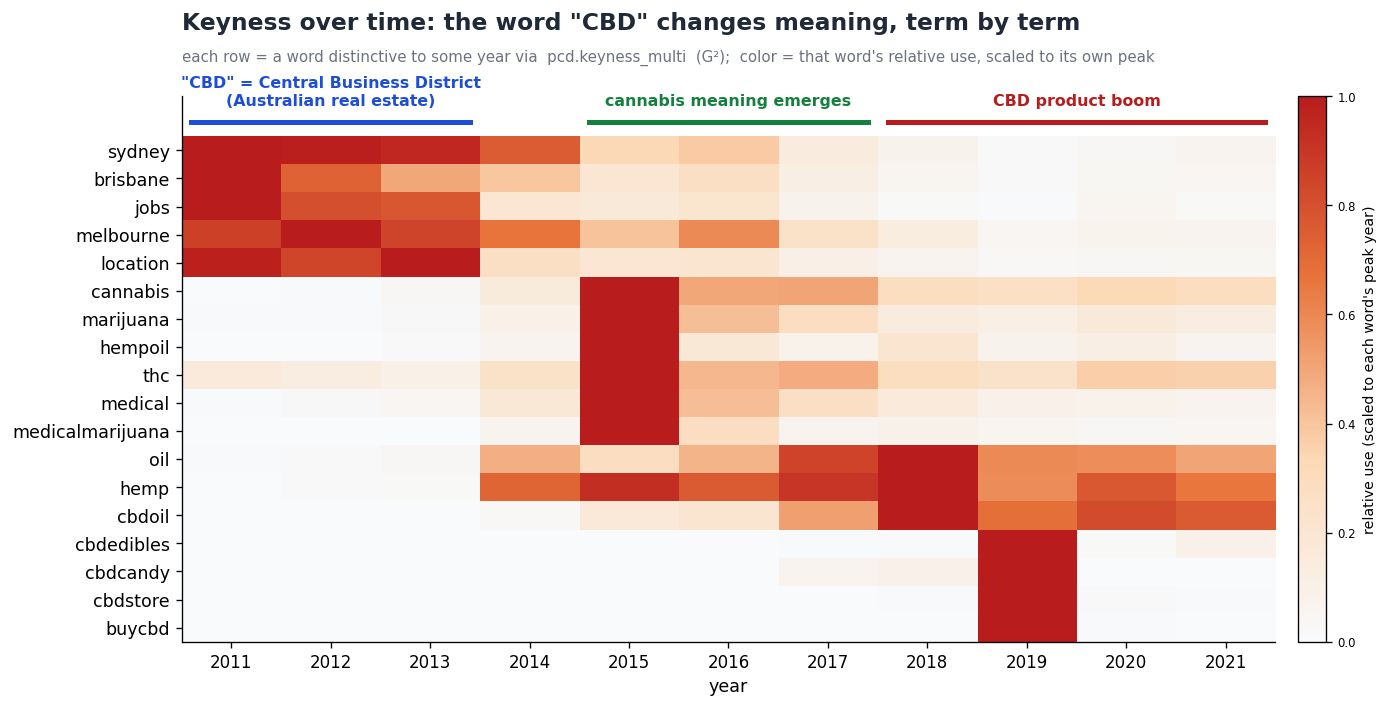

In [3]:
# pcd.keyness_multi: which words are distinctive to each year -> the meaning shift, term by term
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from matplotlib.colors import LinearSegmentedColormap
kyr = list(range(2011, 2022))
KSTOP = set(ENGLISH_STOP_WORDS) | set("cbd rt http https amp co com www im dont didnt ur like just get got new one day today time good great will can also via".split())
kcorp = [pcd.from_dataframe(tw[tw.year == y][["text"]], text_col="text") for y in kyr]
kmm = pcd.keyness_multi(kcorp, labels=[str(y) for y in kyr], stop_words=KSTOP, min_count=30)
kcc = [c for c in kmm.columns if c.startswith("count_")]; krel = kmm[kcc].div(kmm[kcc].sum(0), axis=1)
KJUNK = set("nairobisc mme sc total customer viewed hits".split())
kok = [t for t in kmm.sort_values("g2", ascending=False).index if str(t).isalpha() and len(str(t)) >= 3 and t not in KJUNK][:18]
KR = krel.loc[kok]; KR.columns = [int(c.replace("count_", "")) for c in KR.columns]
KRn = KR.div(KR.max(1), axis=0); KRn = KRn.iloc[np.argsort(KRn.values.argmax(1))]            # order rows by peak year -> diagonal
kcmap = LinearSegmentedColormap.from_list("kw", ["#f8fafc", "#fcd9b6", "#e8743b", "#b91c1c"])
fig, ax = plt.subplots(figsize=(11.5, 6.4)); fig.subplots_adjust(left=0.16, right=0.99, top=0.80, bottom=0.09)
im = ax.imshow(KRn.values, aspect="auto", cmap=kcmap, vmin=0, vmax=1)
ax.set_xticks(range(len(kyr))); ax.set_xticklabels(kyr); ax.set_yticks(range(len(KRn))); ax.set_yticklabels(KRn.index, fontsize=10.5)
ax.set_xlabel("year", fontsize=10.5)
def _era(x0, x1, lab, c):
    ax.plot([x0-0.4, x1+0.4], [-1.0, -1.0], color=c, lw=3, clip_on=False)
    ax.text((x0+x1)/2, -1.5, lab, ha="center", va="bottom", fontsize=9.5, fontweight="bold", color=c, clip_on=False)
_era(0, 2, '"CBD" = Central Business District\n(Australian real estate)', "#1d4ed8")
_era(4, 6, 'cannabis meaning emerges', "#15803d")
_era(7, 10, 'CBD product boom', "#b91c1c")
ax.set_title('Keyness over time: the word "CBD" changes meaning, term by term', fontsize=14, fontweight="bold", color=INK, loc="left", pad=40)
fig.text(0.16, 0.845, "each row = a word distinctive to some year via  pcd.keyness_multi  (G²);  color = that word's relative use, scaled to its own peak", fontsize=9, color=MUTE)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02); cb.set_label("relative use (scaled to each word's peak year)", fontsize=8.5); cb.ax.tick_params(labelsize=7)
plt.show()

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> <code>pycorpdiff</code>'s <b>keyness</b> turns “the word changed meaning” from an assertion into a picture: the distinctive vocabulary marches from <b>sydney / brisbane / jobs</b> (“CBD” = Central Business District) through <b>cannabis / medical</b> to <b>cbd-oil / edibles / buy-cbd</b> — a clean diagonal. But this is the <b>surface</b>, with three limits the embedding methods fix: (1) you must <b>know which words to track</b> — keyness could never have listed <i>semaglutide</i> before GLP-1 claims existed; (2) it <b>can't separate the claim-*types*</b> — cancer-cure, weight-loss, and numbing-cream claims all reduce to <i>cbd</i>+<i>oil</i>; and (3) it <b>can't say which resemble punished fraud</b>. Recovering those needs the geometry of meaning — the rest of this notebook.</div>

### Side 2 — FDA-flagged claims: *we had to build this one*

Nobody hands you a spreadsheet of "health claims the FDA punished." We assembled it from the FDA's warning letters. The pipeline matters because it's *why you can trust the numbers later*:

1. **Get the letters.** The live FDA database (2021–2026), an internet-archive backfill of the older letters the FDA deleted (2014–2020), plus the prescription-drug-promotion letters. ~10,000 letters.
2. **Keep the ones with claims.** Drug/supplement letters carry marketing claims; tobacco/food/factory letters don't. Toss those.
3. **Pull the claims out** with a local AI model reading each letter in overlapping chunks.
4. **The honesty lock (this is the important one):** every claim the model returns is **checked to be a word-for-word quote from the actual letter** — if it isn't, it's thrown away. The model is allowed to *find* quotes; it is *physically not allowed to make them up.*

<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait, what? — How do I know the AI didn't just invent plausible-sounding claims?</b><br> Because of step 4 — and you can watch it happen below. Every single claim is verified to be a literal substring of the source letter. A made-up claim fails the check and never enters the dataset. The code cell prints a live receipt: claim → the actual letter it came from.</div>

In [4]:
# the claims, where they came from, and a LIVE receipt that each is a real quote
display(C.sample(6, random_state=3)[["source", "year", "firm", "claim_text"]])
display(C.groupby("source").agg(claims=("claim_text", "size"), first_year=("year", "min"),
        last_year=("year", "max")).astype({"first_year": "Int64", "last_year": "Int64"}))
norm = lambda s: re.sub(r"\s+", " ", str(s).lower()).strip()
ex = C[C.claim_text.str.contains(r"cancer|cure|tumou?r|anxiety", case=False, na=False) & C.claim_text.str.len().between(28, 85)].iloc[5]
letter = next((D / d / f"{ex.letter_id}.txt").read_text() for d in ["fda_letters", "fda_letters_full"]
              if (D / d / f"{ex.letter_id}.txt").exists())
nl, nc = norm(letter), norm(ex.claim_text); i = nl.find(nc)
assert nc in nl, "guard FAILED — a claim was not a verbatim quote (this must never happen)"   # the honesty lock, enforced
print("EXTRACTED CLAIM :", repr(ex.claim_text))
print(f"CAME FROM       : {ex.firm} · {int(ex.year)} · letter {ex.letter_id}")
print("IS A WORD-FOR-WORD QUOTE FROM THAT LETTER:", nc in nl, "  <-- verified, not asserted on faith")
print("IN CONTEXT      : …" + nl[max(0, i - 80): i + len(nc) + 25] + "…")

,source,year,firm,claim_text
16411,wayback,2018.0,silver armor inc,disable over 650 disease causing pathogens.
30,cbd,2025.0,Holista LLC,Our CBD Horse Pellets helps promote the over a...
15061,wayback,2017.0,ocubright tear stain remover inc,“Epiphora often results in a discoloration cau...
6488,wl,2021.0,"Applied Health Solutions, Inc.","The results of a recent double-blind, placebo-..."
2349,wl,2026.0,"Dripgym Mobile Parent, LLC dba Amp Health",Featuring the same active ingredient found in ...
8831,wayback,2019.0,activeherb technology inc,"recommended by doctors for stomach flu, summer..."


,claims,first_year,last_year
source,,,
cbd,2009,2015,2025
opdp,470,2017,2026
wayback,9292,2014,2020
wl,6681,2021,2026


EXTRACTED CLAIM : 'That’s why our CBD Salve for dogs is recommended for dogs with cancer and tumors.'
CAME FROM       : House of Alchemy/Hamet & Love LLC · 2025 · letter house-alchemy-llc-dba-cbd-dog-health-hamet-love-llc-dba-mycodog-701064-04072025
IS A WORD-FOR-WORD QUOTE FROM THAT LETTER: True   <-- verified, not asserted on faith
IN CONTEXT      : …om growing or spreading, and improved efficiency of existing cancer treatments. that’s why our cbd salve for dogs is recommended for dogs with cancer and tumors.” soothe: hot spots, bug …


<div style="border-left:4px solid #b91c1c;background:#fef2f2;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Remember.</b> The claim dataset is built so the AI can locate real quotes but cannot fabricate any — every row is a verified word-for-word quote from a real FDA letter. That's the trust anchor for everything downstream.</div>

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> <b>"More flagged claims in a year" does <i>not</i> mean "more fraud happened that year."</b> The per-source counts above reflect <i>how many letters we could recover</i> and <i>how actively the FDA was writing them</i> — archive coverage and enforcement effort — not the true amount of fraud in the world. Treat this library as a record of <b>what the regulator punished</b>, never as a fraud census. (We come back to this limit explicitly at the very end — it is the single most important caveat in the project.)</div>

### The library, made searchable (the "RAG")

Those 18,452 claims are loaded into a **search engine for bullshit.** Type a *new* product pitch and it instantly hands back the closest claims the FDA already punished — with the company, the year, and how close the match is.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> It's a bouncer with a little black book of everyone who's been banned. A new face walks up; he flips to the closest match and says 'this one was turned away in 2019, and these three too.' He's not judging your soul — just pattern-matching to known troublemakers.</div>

In [5]:
# type a NEW pitch -> get the nearest already-punished claims (company + year + match score)
from sentence_transformers import SentenceTransformer
_m = SentenceTransformer("all-MiniLM-L6-v2")
def ask(q, k=5):
    qv = L2(_m.encode([q]))[0]; sims = CE @ qv; top = np.argsort(-sims)[:k]
    out = C.iloc[top][["source", "year", "firm", "claim_text"]].copy()
    out.insert(0, "match", sims[top].round(2)); out["year"] = out["year"].astype("Int64")
    print(f'NEW PITCH ▶ "{q}"\n   nearest claims the FDA already punished:')
    return out.reset_index(drop=True)
display(ask("a natural plant compound that shrinks tumors and fights cancer"))
display(ask("gummies that cure insomnia, calm anxiety, and relieve chronic pain"))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

NEW PITCH ▶ "a natural plant compound that shrinks tumors and fights cancer"
   nearest claims the FDA already punished:


,match,source,year,firm,claim_text
0,0.70,cbd,2019,Organix Industries Inc. (d/b/a) Plant Organix,"Anticancer Effects Slowing tumor growth, prote..."
1,0.68,wayback,2015,cancerherbteacom,The plant is also able to destroy cancer cells...
2,0.68,wl,2021,"TeaTaze, LLC","Nettle, a plant that’s been shown exciting pot..."
3,0.68,wl,2023,"Herbal Vitality, Inc.",The herbs [in this formula]…have anti-tumor pr...
4,0.66,wayback,2020,dr sam robbins inc dba hfl solutions llc,Avoid & Treat Cancer: [Curcumin] has been stud...


NEW PITCH ▶ "gummies that cure insomnia, calm anxiety, and relieve chronic pain"
   nearest claims the FDA already punished:


,match,source,year,firm,claim_text
0,0.75,cbd,2019,Daddy Burt LLC (d/b/a) Daddy Burt Hemp Co.,Relieving pain Easing anxiety Helping with ins...
1,0.69,wayback,2015,country doctor herbals,All natural herbal formula that works to relie...
2,0.65,cbd,2019,Daddy Burt LLC (d/b/a) Daddy Burt Hemp Co.,CBD studies have shown evidence that it’s effe...
3,0.64,cbd,2022,ATLRx Inc,The treatment of insomnia is another reason th...
4,0.64,cbd,2022,ATLRx Inc,The treatment of insomnia is another reason th...


<div style="border-left:4px solid #6b7280;background:#f3f4f6;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Where's the "match" score from?</b>  It's <b>cosine similarity</b> — a 0-to-1 "are these two pitches about the same thing" meter (1.00 = basically the same pitch, 0 = unrelated). Every method below runs on this one meter. Think of it as: do two betting slips have the same bets on them?</div>

**How to read the results above.** Each query is a *brand-new* pitch the system has never indexed; it returns the closest already-punished claims, each with a **match score** (1.00 = essentially the same pitch). A high score on *"shrinks tumors"* or *"cures insomnia"* means the new pitch lands right on top of language the FDA already acted against — surfaced **before** any human reads it. That is the entire value proposition in one cell: **triage by resemblance, in milliseconds, against 18,452 known-bad claims.**

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> A high match score means <b>"this resembles something the FDA punished,"</b> not <b>"this is illegal."</b> The search engine <i>retrieves</i>; it never <i>judges</i>. Resemblance is a reason to <b>look</b>, not a verdict — exactly the distinction that will bite us (productively) in the register-recognition section, where the approved drug Epidiolex scores just as "guilty" as a scam.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> You now hold two trustworthy corpora — a decade of public CBD talk and <b>18,452 verified-verbatim</b> FDA-punished claims — plus a single comparison meter (cosine similarity) that turns any claim into something measurable against the rest. <b>Everything downstream is clever bookkeeping on that one meter.</b> Trust the data and the meter, and the rest of the notebook follows.</div>

## How do you measure "the talk changed"? Two bouncers.

Everything rides on one move: turn each claim into a **fingerprint** (a list of numbers) so a computer can measure how similar two claims are. Similar pitches get similar fingerprints. Now "did the talk change?" becomes "are this year's fingerprints unlike the ones we knew before?"

There are two honest ways to ask that — and we use **both on purpose**, because if two methods that work completely differently agree, you stop suspecting a fluke.

<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait, what? — What's a 'fingerprint' (an embedding)?</b><br> A claim like "shrinks tumors" gets turned into ~384 numbers that capture its meaning. Two claims that mean similar things land near each other. You never read the numbers — you just measure distances between them. (Like two snake-oil pitches that promise the same miracle: "shrinks tumors" and "melts cancer away" read almost identically, so they land on the same shelf.)</div>

### Method 1 — *the regulars-and-strangers bouncer* (sense_drift, the TJ/Kantardzic method)

**One sentence:** learn what the *normal kinds* of claims looked like in a baseline period, then each later year count what fraction of claims don't fit any known kind — when that "stranger rate" jumps, the topic changed.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> A bouncer memorizes the regular crowd — the familiar faces he waves through every night. Each night he counts the faces that fit none of them. A few strangers is normal. The night half the room is faces he's never seen — *that's* the night the crowd changed.</div>

<div style="border:1px solid #d1d5db;border-radius:6px;padding:12px 16px;margin:8px 0;background:#fbfbfd"><b>Worked example — the "stranger" score</b><br><br>A new claim's closest match to any known "kind" scores <b>0.55</b> similar. Its <i>strangeness</i> is one minus that:
$$\text{strangeness} = 1 - 0.55 = \mathbf{0.45}$$
In the baseline period, 95% of claims scored below <b>0.30</b> strange — call that the <b>stranger line</b>. Since
$$0.45 \;>\; 0.30,$$
this claim counts as a <b>stranger</b>. Now suppose <b>18%</b> of this year's claims are strangers, while the baseline ran at <b>5%</b> give-or-take <b>2%</b>. How alarming is 18%?
$$\frac{18\% - 5\%}{2\%} = \mathbf{6.5\ \text{standard deviations}}\ \text{above normal} \;\Rightarrow\; \textbf{alarm.}$$</div>

<div style="border-left:4px solid #6b7280;background:#f3f4f6;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Where are these knobs from? (3 of them — only one actually matters)</b>  <b>(1) Number of "kinds" = 6.</b> A resolution knob — how many buckets you sort the baseline into. Nudge it and the picture barely moves. Cosmetic.<br><b>(2) Stranger line = 95th percentile.</b> A starting line — by definition 5% of baseline claims are "strangers." Move it and the absolute percentages shift, but <i>when</i> the spike happens does not. Convention.<br><b>(3) Alarm sensitivity = 3 standard deviations.</b> <b>This is the only dial you can feel.</b> "Don't cry wolf unless a year is clearly past normal noise." Lower it → twitchier, more false alarms; higher → calmer, misses small shifts. 3 is the standard "that's real, not noise" bar.</div>

### A 20-second decoder for the two math boxes

The two **"The algorithm, precisely"** boxes below are the exact recipe in symbols, and they're **skip-safe** — the bouncer already gave you the whole idea. If you *do* read them, here's the entire alphabet, in plain words and bar terms (nothing in those boxes uses a symbol that isn't here):

| symbol you'll see | plain English | the everyday picture |
|:--|:--|:--|
| **x̂** | a claim turned into a number-"fingerprint" | a face |
| **cos(a, b)** | how alike two claims are, 0–1 | "do these two look alike?" |
| **ν(x)** &nbsp;*(say "nu")* | a claim's **strangeness**, 0–1 | how unfamiliar this face is |
| **θ** &nbsp;*(say "theta")* | the **stranger line** — a cutoff | "past this, you're a stranger" |
| **Q₉₅** | the 95th-percentile value (95% fall below it) | where you draw "unusual" |
| **1[ … ]** | counts 1 if the bracketed thing is true, else 0 | a tally mark |
| **MD** *(in year t)* | the **stranger rate** that year | % unfamiliar faces tonight |
| **μ, σ** &nbsp;*(say "mu, sigma")* | the baseline average, and its normal wiggle | a normal night, give or take |
| **μ + 3σ** | "clearly past a normal night" | the alarm line |
| **P (year t), R** | this year's claims; the baseline set | tonight's crowd; the regulars |

**The five steps in one breath, before the symbols.** *Learn the normal kinds of claims → score how strange each new claim is → draw a "stranger line" → count what fraction of each year are strangers → sound the alarm when that fraction spikes past normal noise.* Everything in the box below is just that one sentence, written precisely. If the sentence makes sense, you already understand the method.

**The algorithm, precisely (Method 1).** **Skip-safe** — you already have this from the bouncer; below is the same idea written exactly, for anyone who wants to verify it. Every symbol is in the decoder above.

Each claim is an embedding $x \in \mathbb{R}^{384}$, used L2-normalized $\big(\hat x = x/\lVert x\rVert_2\big)$, so **cosine similarity is just a dot product**:

$$\cos(a,b)=\frac{a\cdot b}{\lVert a\rVert_2\,\lVert b\rVert_2}=\hat a\cdot\hat b\;\in[-1,1]\qquad(\textit{how alike two claims are; }1=\textit{identical direction})$$

**Step 1 — learn the kinds.** Fit $k=6$ centroids $c_1,\dots,c_k$ by $k$-means on the reference window $R$. *(Sort the baseline crowd into cliques.)*

**Step 2 — strangeness.** $\displaystyle \nu(x)=1-\max_{1\le j\le k}\cos(\hat x,\hat c_j)$ &nbsp; *(one minus similarity to the nearest clique; far from all $\Rightarrow \nu\approx 1$).*

**Step 3 — stranger line.** $\theta=Q_{0.95}\big(\{\nu(x):x\in R\}\big)$, the 95th percentile of baseline strangeness; a claim is **novel** iff $\nu(x)>\theta$. *(By construction 5% of the baseline counts as "strange.")*

**Step 4 — margin density** (the signal), for period $t$ with claims $P_t$:

$$\mathrm{MD}_t=\frac{1}{|P_t|}\sum_{x\in P_t}\mathbf 1\!\left[\nu(x)>\theta\right]\qquad(\textit{that year's stranger rate})$$

**Step 5 — alarm (control chart).** With baseline mean $\mu_R$ and standard deviation $\sigma_R$ of $\mathrm{MD}$ across reference periods,

$$\text{flag } t \iff \mathrm{MD}_t > \mu_R + \kappa\,\sigma_R,\qquad \kappa=3,$$

confirmed only inside a run of $\ge m=2$ consecutive flagged periods. *(Fire when a year sits 3 SDs past baseline noise — twice running.)*

This is the **TJ/Kantardzic** method — **Sethi & Kantardzic (2017), Margin-Density Drift Detection**: monitor the *density of the uncertainty region* — here, claims outside every learned sense — on a control chart, imported from classifier-monitoring into lexical change. A complementary **Jensen–Shannon divergence** on the $(k{+}1)$-bin sense histogram (the $k$ senses plus one "novel" bin) catches pure *re-weighting* of known senses; the flagged change is then typed **emergence / broadening / frequency-shift**. *(We use cosine novelty, not Mahalanobis: Mahalanobis saturates — pins at 1 — when the whole embedding cloud shifts across eras.)*

### Method 2 — *the lazy bouncer* (knn_density_drift, the KNN method)

**One sentence:** skip defining "kinds" entirely — for each claim just ask "does this look like *anyone* we already knew?"; if even its single closest match is a stranger, flag it, and count those per year.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> Same door, lazier bouncer. He doesn't bother grouping the regulars into cliques. He just asks each face: 'do you look like literally anyone I've seen before?' If the closest match is still a stranger, flag it. Less bookkeeping, same instinct.</div>

<div style="border:1px solid #d1d5db;border-radius:6px;padding:12px 16px;margin:8px 0;background:#fbfbfd"><b>Worked example — "is your closest match still a stranger?"</b><br><br>A claim's <i>single closest</i> match among everything we already knew scores <b>0.62</b> similar:
$$\text{strangeness} = 1 - 0.62 = \mathbf{0.38}$$
Same stranger line as before, <b>0.30</b>. Since
$$0.38 \;>\; 0.30,$$
it's a <b>stranger</b> — and we never had to define a single "kind." Count the stranger-fraction each year; when it climbs, the talk drifted.</div>

**In one breath, before the symbols:** *same skeleton as Method 1 — only the definition of "strangeness" changes.* Instead of distance to fitted cliques, measure distance to a claim's nearest neighbors. Exactly one line of the recipe differs; everything else is reused verbatim.

**The algorithm, precisely (Method 2).** **Skip-safe again** — same decoder, same skeleton, **no clusters**. Reuse $\hat x$, $\cos$, the stranger line $\theta$, the margin density $\mathrm{MD}_t$, and the control chart from Method 1. Only the strangeness score changes.

**Strangeness (k-nearest-neighbor).** For a claim $x$ and a comparison set $S$, let $\hat r_{(1)},\dots,\hat r_{(k)}$ be its $k$ highest-cosine neighbors in $S$ (we use $k=10\text{–}15$):

$$\nu(x)=1-\frac{1}{k}\sum_{i=1}^{k}\cos\!\big(\hat x,\hat r_{(i)}\big)\qquad(\textit{one minus the average closeness of its }k\textit{ nearest matches})$$

*(The worked example above used $k=1$ — the single nearest — for clarity; in practice we average the $k$ nearest to denoise.)*

**Which comparison set $S$?** This is the one real choice:

$$S=\begin{cases}\,R & \textbf{reference mode} \;\;\text{— novelty vs a fixed baseline}\\[4pt] \,\{x' : t(x')<t(x)\} & \textbf{streaming mode} \;\;\text{— novelty vs everything strictly earlier}\end{cases}$$

Streaming mode can be replayed forward and **never sees the future** — it is the mode behind the early-warning backtest below.

Everything else is identical to Method 1: stranger line $\theta=Q_{0.95}\big(\{\nu(x):x\in R\}\big)$, margin density $\mathrm{MD}_t=\tfrac{1}{|P_t|}\sum_{x\in P_t}\mathbf 1[\nu(x)>\theta]$, and the flag $\mathrm{MD}_t>\mu_R+3\sigma_R$ over a run $\ge 2$. The single structural change — distance to **neighbors** instead of to **fitted clusters** — is exactly what makes it (a) **streaming-capable** (add a point, query its neighbors, no re-fit) and (b) robust when the whole embedding cloud shifts (there is no cluster model to break).

<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Why bother with two methods?</b>  Because they're built on <i>different</i> assumptions — one groups the regulars into cliques, the other ignores cliques entirely. If the careful bouncer and the lazy bouncer <b>both</b> say "the crowd changed in 2024," it isn't a quirk of how someone drew the cliques. Agreement between two unlike methods is the cheapest honesty check there is.</div>

In [6]:
# Re-derive the two worked examples in code so the hand numbers can't drift, then run BOTH detectors live
assert round(1 - 0.55, 2) == 0.45 and round(1 - 0.62, 2) == 0.38            # the strangeness scores
assert round((0.18 - 0.05) / 0.02, 1) == 6.5                                # the "6.5 sigma" alarm
yrs = sorted(C.year.dropna().unique()); REF = [y for y in yrs if y <= yrs[0] + 4][:5]
sd = pcd.sense_drift(C, CE, "year", reference=REF, k=6, novelty="cosine", text_col="claim_text")        # regulars-and-strangers
kn = pcd.knn_density_drift(C, CE, "year", reference=REF, k=10, mode="reference", text_col="claim_text")  # lazy bouncer
print("baseline years:", [int(y) for y in REF])
print("regulars-and-strangers (sense_drift):", sd.summary())
print("lazy bouncer        (knn_density)   :", kn.summary())

baseline years: [2014, 2015, 2016, 2017, 2018]
regulars-and-strangers (sense_drift): Sense drift detected from 2024.0 (2 period(s) flagged); change type: broadening (margin density 0.152, JSD 0.037). Distinctive terms: median, dysphoria, gender, smelling, ozempic, generic, ammonia, endoscopic.
lazy bouncer        (knn_density)   : k-NN-density drift detected from 2020.0 (7 period(s) flagged; novelty density 0.133, mode=reference).


**How to read those two summary lines.** Each detector reports the **first year it flagged**, **how many periods** tripped the alarm, and its signal value. `sense_drift` adds something `knn_density_drift` can't: a **change type** —

- **emergence** — a brand-new, tight cluster of claims appears (a genuinely new kind of pitch),
- **broadening** — the *range* of topics widens (more kinds at once),
- **frequency-shift** — the same old topics, but in new proportions —

plus a few **distinctive terms** naming what changed. So you don't just learn *that* the FDA's focus moved; you get a one-line label for *how* it moved. The **baseline years** printed first are the "normal" both detectors calibrated against — every later year is judged relative to them, never the other way around.

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> The <b>"3 standard deviations"</b> alarm is a <i>control-chart</i> rule, not a p&lt;0.001 significance test. The yearly periods are not independent coin-flips (this year resembles last year), so don\'t read "3σ" as a textbook p-value. The defenses against a fluke are deliberately <b>stacked</b>: the spike must <b>persist ≥2 years in a row</b>, an optional <b>permutation test</b> backs <code>sense_drift</code>, and — above all — <b>two mechanically different detectors must agree</b> (the cross-check we build toward in the zoom-out).</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> Two detectors, one skeleton: fingerprint every claim, fix a <b>stranger line</b>, and count how many of each year's claims fall past it. <code>sense_drift</code> first groups the baseline into kinds — so it can <i>name</i> the change; <code>knn_density_drift</code> skips the grouping — so it can run <i>live</i>, one point at a time. Same instinct, different bookkeeping. That difference is the whole reason their later <b>agreement</b> carries weight: a shared blind spot is unlikely when the machinery isn't shared.</div>

## Could we have seen CBD coming?

Now the payoff. We take the lazy-bouncer monitor, freeze its idea of "normal" on the **pre-craze 2011–2012** tweets, and **replay history forward** — it only ever sees the past, never the future. We watch when its alarm trips, and compare that to when the FDA actually started cracking down.

**This is the flagship demonstration of the *catch* side.** The monitor runs **streaming and forward-only**: each year is scored using just the frozen 2011–12 baseline, so it could have been computed **live, in that very year** — no peeking ahead, no re-fitting. If `knn_density_drift` is meant for early warning, this is where it has to earn it.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> The miracle-cure language shows up in the ads years before the FDA's warning letter shows up in the mail. The question isn't 'was it snake oil' — we know now. It's 'could you have called it from the early ads?'</div>

monitor first trips 2014, stays tripped from 2016  |  FDA crackdown wave 2019  |  LEAD 3–5 years


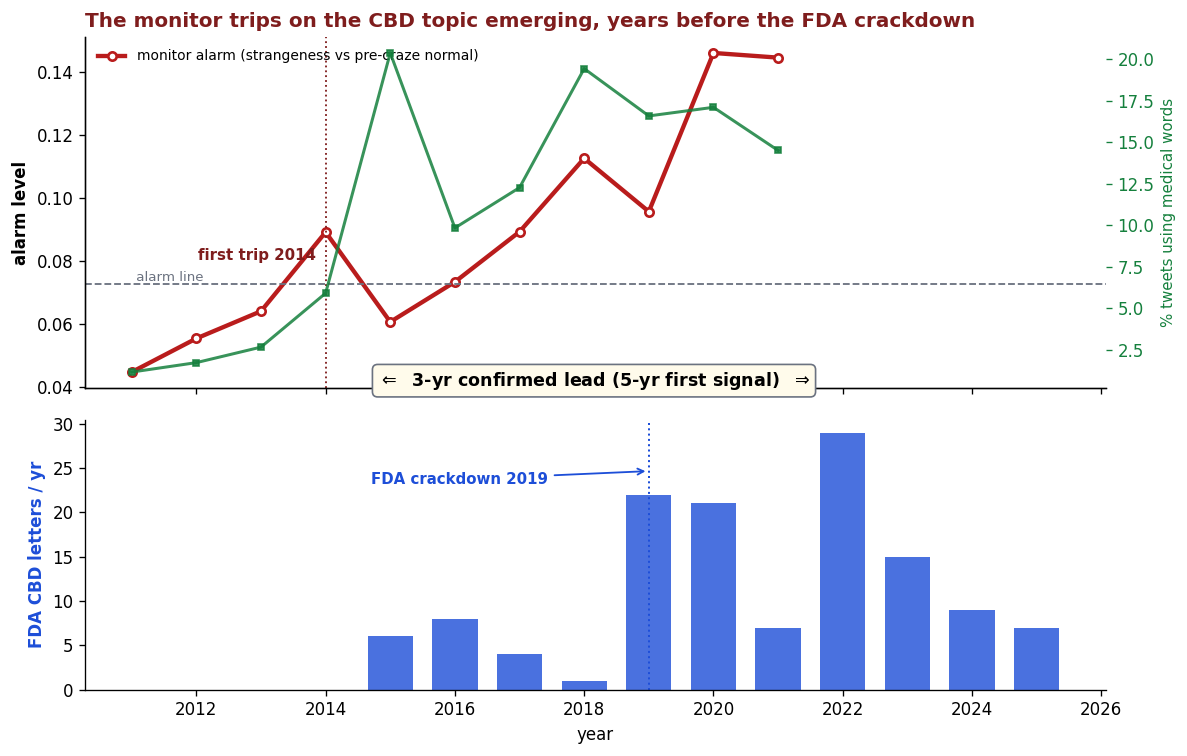

In [7]:
# replay the monitor forward over CBD tweets; default settings, no peeking at the future
res = pcd.knn_density_drift(tw, TE, "year", reference=[2011, 2012], k=15, mode="reference", min_run=2, text_col="text")
al = res.table.sort_values("period").reset_index(drop=True)
MED = re.compile(r"\b(?:cure[sd]?|treat\w*|cancer|anxiety|pain|inflam\w*|seizure|epilep\w*|arthritis|insomnia|depress\w*|tumou?rs?|heal\w*|remed\w*|therapeutic|disease|disorder|chronic)\b", re.I)
medfrac = tw.assign(med=tw.text.str.contains(MED, regex=True)).groupby("year").med.mean()
L = pd.read_parquet(D / "fda_warning_letters.parquet")
enf = L.dropna(subset=["year"]).assign(year=lambda d: d.year.astype(int)).year.value_counts().sort_index()
first_cross = int(al[al.novelty_density > res.threshold].period.min()); sustained = int(al[al.drift].period.min()); wave = int(enf[enf >= 15].index.min())
assert first_cross == 2014 and sustained == 2016 and wave == 2019                  # lock the dates shown below
print(f"monitor first trips {first_cross}, stays tripped from {sustained}  |  FDA crackdown wave {wave}  |  LEAD {wave-sustained}–{wave-first_cross} years")

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})
yy = al.period.values; nd = al.novelty_density.values
ax.plot(yy, nd, color=RED, lw=2.6, marker="o", ms=5, mfc="white", mec=RED, mew=1.6, label="monitor alarm (strangeness vs pre-craze normal)")
ax.axhline(res.threshold, ls="--", lw=1.1, color=MUTE); ax.text(2011, res.threshold, " alarm line", va="bottom", fontsize=8, color=MUTE)
ax.axvline(first_cross, color=DARK, lw=1.1, ls=":"); ax.text(first_cross - 0.15, nd.max()*0.55, f"first trip {first_cross}", ha="right", fontsize=9, fontweight="bold", color=DARK)
axm = ax.twinx(); axm.plot(medfrac.index, medfrac.values*100, color=GREEN, lw=1.8, marker="s", ms=3.5, alpha=0.85)
axm.set_ylabel("% tweets using medical words", color=GREEN, fontsize=9); axm.tick_params(axis="y", colors=GREEN)
ax.set_ylabel("alarm level", fontweight="bold"); ax.legend(loc="upper left", frameon=False, fontsize=8.3)
ax.set_title("The monitor trips on the CBD topic emerging, years before the FDA crackdown", color=DARK, loc="left")
ax2.bar(enf.index, enf.values, color=BLUE, alpha=0.8, width=0.7)
ax2.axvline(wave, color=BLUE, lw=1.2, ls=":"); ax2.annotate(f"FDA crackdown {wave}", (wave, enf.max()*0.85), xytext=(wave-4.3, enf.max()*0.8), fontsize=9, fontweight="bold", color=BLUE, arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.1))
ax2.set_ylabel("FDA CBD letters / yr", fontweight="bold", color=BLUE); ax2.set_xlabel("year")
fig.text(0.5, 0.49, f"$\\Leftarrow$  {wave-sustained}-yr confirmed lead ({wave-first_cross}-yr first signal)  $\\Rightarrow$", ha="center", fontsize=10.5, fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc="#fffbeb", ec=MUTE))
plt.tight_layout(); plt.show()

**How to read the chart.** *Top panel:* the **red line** is the monitor's alarm level each year — how strange that year's tweets look against the frozen 2011–12 baseline; the **dashed line** is the alarm threshold; the **green line** is the share of tweets using medical words. *Bottom panel:* the FDA's **actual** CBD warning letters per year. The whole argument is the **horizontal gap** — the red alarm crosses its line years to the *left* of the blue enforcement wave. And the green line rising in step with the red alarm is the *consistency check*: it tells you the alarm is reacting to the medical reframing, not to random churn.

<div style="border-left:4px solid #6b7280;background:#f3f4f6;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Where's "3–5 years" from?</b>  Two honest readings, both shown. The alarm <b>first trips in 2014</b> (a one-year blip) and <b>stays tripped from 2016</b> (the conservative number — same "2 years in a row" rule as the detector). The FDA's crackdown <i>wave</i> (first year with ≥15 CBD letters) is <b>2019</b>. So 2019−2016 = <b>3 years</b> conservatively, 2019−2014 = <b>5</b> at the first whiff. Not cherry-picked — both ends are on the table.</div>

<div style="border-left:4px solid #b91c1c;background:#fef2f2;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Remember.</b> Frozen on 2011–12 and replayed forward, the monitor flags the **CBD topic emerging** ~3 years before the FDA's crackdown. **Honest caveat:** *"CBD" is polysemous* — early tweets are overwhelmingly *Central Business District* (city/traffic), only ~4% cannabidiol — so this lead is **topic-level** (a keyword count catches it too, even earlier). Within cannabidiol tweets the health signal is **flat** across the decade; the *health-specific* read comes from the **register test**, not the timeline.</div>

<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait, what? — Isn't this hindsight? You know CBD blew up.</b><br> The settings are defaults and the baseline is frozen on 2011–12 — the replay never sees past the year it's scoring, and nothing was tuned to make CBD look good. It's a fair backtest, not a story fit after the fact. And honest limit: it detects that CBD *health talk emerged* — not that it was *fraud* (more on that next).</div>

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> Two over-reads to resist. <b>(1) Co-movement is not comprehension.</b> The green medical-words line rising with the alarm shows the alarm is tracking the right thing — but it does not prove the monitor "understands" CBD. It measures <i>unfamiliarity</i>, which here happened to coincide with medicalization. <b>(2) One product is not a forecast horizon.</b> "3–5 years" is the lead time on <i>this</i> case; it is not a guaranteed warning time for the next product. This is a worked demonstration on a known outcome, not a validated service-level guarantee.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> Frozen on 2011–12 and replayed forward with <b>default settings and no peeking at the future</b>, the monitor raised a <b>confirmed, sustained alarm 3 years before</b> the FDA's crackdown wave (2016 vs 2019) — with an earlier, unconfirmed one-year blip 5 years out. That is the core promise of the whole approach — <b>early warning from public talk alone</b> — demonstrated on the one case where we can score it against the regulator's real timeline. Keep the limit in view: the alarm fires on <i>emergence</i>, not on <i>fraud</i>.</div>

### Baseline check: do you even *need* embeddings for this?

A fair reviewer asks the obvious: *couldn't you just count health-words over time?* So we did — took a hand-built health-claim word list, tracked its frequency in the CBD tweets, and ran the **same** control-chart alarm. Here's the honest head-to-head (we report it even though it doesn't flatter us).

In [8]:
# B1 baseline: would a simple KEYWORD count have flagged CBD as early as the embedding monitor?
mf = medfrac * 100                                                        # health-word % per year (from the backtest cell)
b2 = mf[mf.index <= 2012]; kthr = float(b2.mean() + 3*b2.std())
kw_alarm = int(mf[mf > kthr].index.min())                                 # keyword control-chart: first alarm year
print(f"keyword-trend baseline (control chart, mu+3sigma = {kthr:.1f}%): first alarm = {kw_alarm}")
print(f"embedding monitor: first alarm = {first_cross}   |   FDA enforcement wave: {wave}")
cmp = pd.DataFrame([
    {"method": "keyword-trend (hand-built word list)", "needs a word list?": "yes", "catches paraphrases?": "no", "does register-recognition?": "no", "first flagged CBD": kw_alarm},
    {"method": "embedding monitor (ours)",             "needs a word list?": "no",  "catches paraphrases?": "yes", "does register-recognition?": "yes", "first flagged CBD": int(first_cross)},
    {"method": "FDA enforcement (the regulator)",      "needs a word list?": "—",   "catches paraphrases?": "—",  "does register-recognition?": "—",  "first flagged CBD": int(wave)},
])
display(cmp.style.hide(axis="index")
        .set_properties(**{"text-align": "left", "font-size": "10.5pt", "padding": "4px 11px"})
        .set_properties(subset=["does register-recognition?"], **{"font-weight": "bold"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10.5pt"), ("padding", "4px 11px")]}]))

keyword-trend baseline (control chart, mu+3sigma = 2.7%): first alarm = 2013
embedding monitor: first alarm = 2014   |   FDA enforcement wave: 2019


method,needs a word list?,catches paraphrases?,does register-recognition?,first flagged CBD
keyword-trend (hand-built word list),yes,no,no,2013
embedding monitor (ours),no,yes,yes,2014
FDA enforcement (the regulator),—,—,—,2019


<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> <b>Honest verdict: on the CBD case a keyword count matches our timing — but only because the word list was built with <i>hindsight</i>.</b> It alarms in 2013, a year before the embedding monitor — yet that flatters keywords for the reason that <i>is</i> the point: <b>keyword early-detection is needle-in-haystack</b>, it can only fire on a misinfo type someone already thought to enumerate. You couldn't have written this list in 2011 without already knowing CBD would matter, and it has <b>no term for COVID-cure or GLP-1 claims before they exist</b> — so on the enforcement frontier it would miss both waves by construction, where our <b>label-free</b> detectors flag them with no foreknowledge. So timing on a <i>known</i> target isn't the win. Embeddings earn their keep on the things a fixed list <b>cannot</b> do: <b>label-free detection of unknown types</b> (no needle), <b>paraphrases</b> a list misses, and above all <b>register-recognition</b> — resemblance to <i>prior</i> fraud. <b>Those are the contribution.</b></div>

## Did CBD's claims *sound like* scams the FDA already knew?

Sharper question. Build a "known-scam phrasebook" from **only the pre-CBD, non-CBD** letters — bullshit the FDA had already punished on *other* products, before CBD was a thing. Then ask: do CBD's own claims match that phrasebook?

**This is the flagship demonstration of the *recognize* side** — the payoff of treating the FDA's entire back-catalogue as a reusable library. It's the complement to the backtest: the monitor above catches *new-and-strange*; this asks whether the strange thing also *sounds like fraud we already knew*. New product × old-fraud-grammar is the highest-priority flag there is.

Think of it as the **zoom-in**: later we zoom *out* and watch the whole fraud frontier move across every product (the two-detector monitor); here we zoom *in* on a single product — **CBD** — and ask whether the FDA's *older, unrelated* busts already recognize it.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> A new tonic's sales pitch reads word-for-word like three products the FDA already shut down. You don't need to wait for someone to get hurt — the *patter* is a known con. The file on it was written before the bottle ever hit the shelf.</div>

**See it first, before any statistic.** Here are real CBD claims placed next to the closest claim the FDA had **already punished on a completely different product** — herbal teas, essential oils, supplements — usually *years earlier*. The match is found purely by *meaning* (no shared keywords required): "reduces blood sugar" finds "reduces the glucose level in blood." Same pitch, new label.

In [9]:
# the rhyme, shown: each NEW CBD claim beside the OLDER, DIFFERENT-product bust it most resembles
from IPython.display import HTML
isCBD = C.claim_text.str.contains(r"\bcbd\b|cannabidiol|hemp", case=False, na=False) | (C.source == "cbd")
cbdm = (C.source == "cbd").to_numpy(); cbd = C[cbdm].reset_index(drop=True)
CAN = r"\bcbd\b|cannab|hemp|canna|marij|\bthc\b|kush|\bweed\b|dispensar"                 # exclude ALL cannabis-adjacent
cantext = (C.claim_text.fillna("") + " " + C.firm.fillna("")).str.contains(CAN, case=False)
priorR = ((C.year <= 2016) & (~isCBD) & (~cantext)).to_numpy()                            # OLD + genuinely different products
REx = CE[priorR]; Rx = C[priorR].reset_index(drop=True)
nrm = lambda s: re.sub(r"[^a-z0-9 ]", " ", re.sub(r"\s+", " ", str(s).lower())).strip()
rows = []
for label, pat in [("cancer", r"cancer|tumou?r"), ("anxiety", r"anxiety|stress"), ("pain / inflammation", r"\bpain\b|inflam"),
                   ("immune", r"immune"), ("blood sugar", r"diabet|blood sugar|glucose"), ("seizures", r"seizure|epilep")]:
    sel = (cbd.claim_text.str.contains(pat, case=False, na=False) & cbd.claim_text.str.len().between(20, 95)).to_numpy()
    if not sel.any(): continue
    idx = np.where(sel)[0]; Smat = CE[cbdm][idx] @ REx.T
    for ci, ri in np.dstack(np.unravel_index(np.argsort(-Smat, axis=None), Smat.shape))[0][:400]:
        if Smat[ci, ri] < 0.55: break
        cc, pp = cbd.iloc[idx[ci]], Rx.iloc[ri]
        if nrm(cc.claim_text) == nrm(pp.claim_text): continue                              # show a real paraphrase, not a dup
        _q = chr(8220) + chr(8221) + chr(34) + chr(39) + " "                          # strip stray surrounding quotes
        rows.append((label, int(cc.year), " ".join(cc.claim_text.split()).strip(_q)[:68], int(pp.year), str(pp.firm)[:24].title(),
                     " ".join(str(pp.claim_text).split()).strip(_q)[:68], float(Smat[ci, ri]))); break
RHY = pd.DataFrame([{"condition": l, "the NEW CBD claim": f"“{ct}”  ({cy})",
                     "the OLD, different-product bust it rhymes with": f"“{pt}”  —  {pf}, {py}",
                     "match": round(s, 2)} for (l, cy, ct, py, pf, pt, s) in rows])
display(RHY.style.hide(axis="index")
        .background_gradient(subset=["match"], cmap="Reds", vmin=0.5, vmax=1.0)
        .set_properties(**{"text-align": "left", "font-size": "10pt", "padding": "5px 11px"})
        .set_properties(subset=["the NEW CBD claim"], **{"color": "#b91c1c", "font-weight": "bold"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10pt"), ("padding", "5px 11px")]}]))
print("Every 'old' claim is a DIFFERENT product (teas, oils, supplements) the FDA punished earlier — matched by meaning, not keywords.")

condition,the NEW CBD claim,"the OLD, different-product bust it rhymes with",match
cancer,“will kill cancer cells” (2022),"“Kills Cancer Cells” — Cancerherbteacom, 2015",0.900000
anxiety,“Alleviates anxiety” (2016),"“Anxiety Relief” — Terra Firma Botanicals, 2016",0.850000
pain / inflammation,“Reduce Inflammation” (2022),"“Reduces Inflammation” — Jw Nutritional Llc Dalla, 2015",0.960000
immune,“Strengthens immune system” (2016),"“Immune System Strengthener” — Doterra International Ll, 2014",0.960000
blood sugar,“Reduces blood sugar levels” (2019),"“Reduces the glucose level in blood” — Borinquen Natural Inc, 2014",0.890000
seizures,“It May Help Avoid Seizures” (2024),"“It significantly reduces the frequency and severity of seizures.” — Buck Mountain Herbs Bota, 2016",0.790000


Every 'old' claim is a DIFFERENT product (teas, oils, supplements) the FDA punished earlier — matched by meaning, not keywords.


Coincidence, or a pattern? The pairs above are hand-picked illustrations — so now make it systematic. Build the "known-scam phrasebook" from **every** pre-CBD, non-CBD punished claim and measure how strongly CBD's claims, as a whole, resemble it.

phrasebook size: 3071 pre-CBD non-CBD claims
matches the phrasebook:  CBD claims 45%   |   legit medical writing 5%   |   unrelated text 0%   ->  9x the control
HONEST CATCH: CBD-epilepsy (the claim that became the APPROVED drug Epidiolex) matches at 0.56  ≈  CBD-cancer (scam) at 0.59


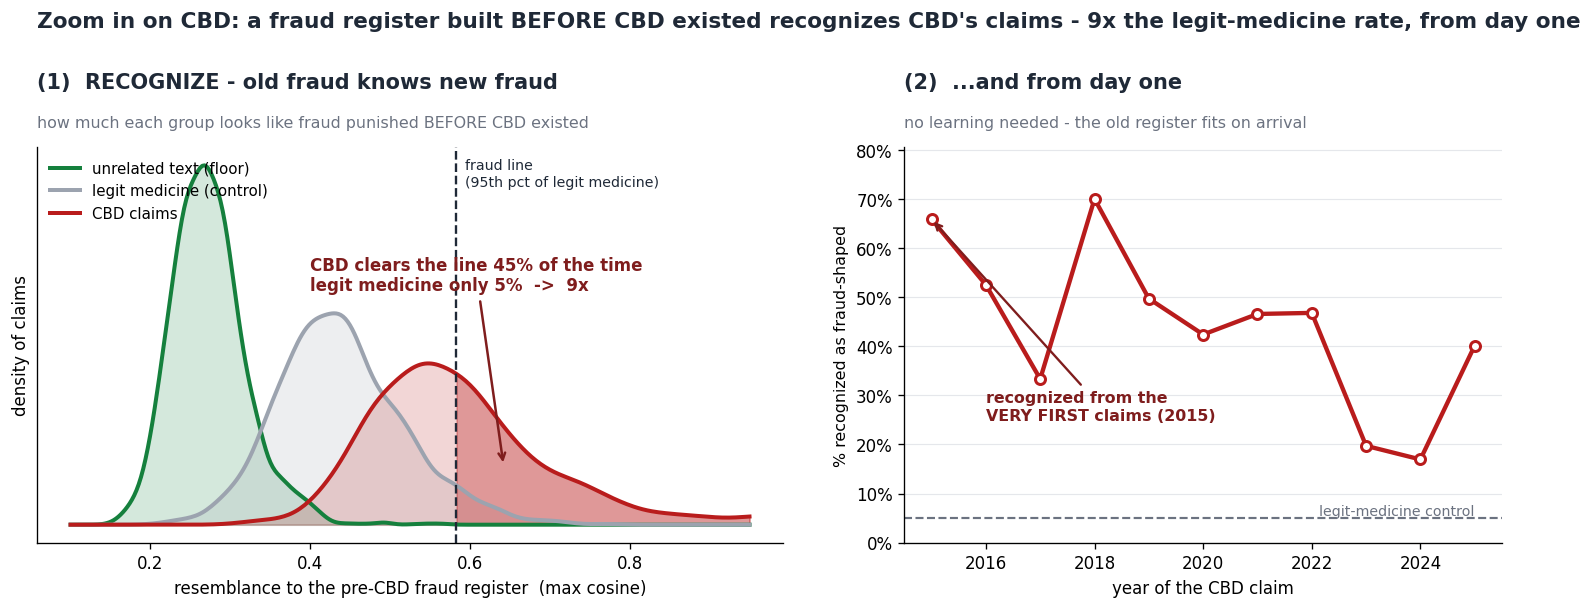

In [10]:
# does a pre-CBD, non-CBD "known-scam" phrasebook recognize CBD's claims?
isCBD = C.claim_text.str.contains(r"\bcbd\b|cannabidiol|hemp", case=False, na=False) | (C.source == "cbd")
RE = CE[((C.year <= 2016) & (~isCBD)).to_numpy()]                                  # the phrasebook: pre-2016, non-CBD only
near = lambda X: np.concatenate([(X[i:i+4000] @ RE.T).max(1) for i in range(0, len(X), 4000)])
ps = near(L2(np.load(D / "pubmed_background_embeddings.npy"))); T = float(np.percentile(ps, 95))   # legit medical writing = control
ds = near(L2(np.load(D / "crec_drone_embeddings.npy")))                                            # unrelated text = floor
cbdm = (C.source == "cbd").to_numpy(); cbd = C[cbdm].reset_index(drop=True); cbd["sim"] = near(CE[cbdm])
rate, pm, dr = (cbd.sim > T).mean(), (ps > T).mean(), (ds > T).mean()
lift = rate / pm
assert round(lift) == 9 and round(100 * pm) == 5                                   # lock the "9x vs 5% control" as shown
byyr = (cbd.groupby(cbd.year.astype("Int64")).apply(lambda d: (d.sim > T).mean()) * 100).dropna()
epi = cbd.claim_text.str.contains(r"epilep|seizure|dravet", case=False).to_numpy()
canc = cbd.claim_text.str.contains(r"cancer|tumou?r", case=False).to_numpy()
print(f"phrasebook size: {RE.shape[0]} pre-CBD non-CBD claims")
print(f"matches the phrasebook:  CBD claims {100*rate:.0f}%   |   legit medical writing {100*pm:.0f}%   |   unrelated text {100*dr:.0f}%   ->  {lift:.0f}x the control")
print(f"HONEST CATCH: CBD-epilepsy (the claim that became the APPROVED drug Epidiolex) matches at {cbd.sim[epi].mean():.2f}  ≈  CBD-cancer (scam) at {cbd.sim[canc].mean():.2f}")

from scipy.stats import gaussian_kde
fig = plt.figure(figsize=(13.2, 5.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1], wspace=0.18, left=0.06, right=0.985, top=0.74, bottom=0.13)
axA = fig.add_subplot(gs[0]); xx = np.linspace(0.1, 0.95, 300); cbd_kde = gaussian_kde(cbd.sim.values)
for vals, c, lab in [(ds, GREEN, "unrelated text (floor)"), (ps, GREY, "legit medicine (control)"), (cbd.sim.values, RED, "CBD claims")]:
    yk = gaussian_kde(vals)(xx); axA.fill_between(xx, yk, color=c, alpha=0.18); axA.plot(xx, yk, color=c, lw=2.4, label=lab)
ytop = axA.get_ylim()[1]
axA.axvline(T, ls="--", lw=1.4, color=INK); axA.text(T, ytop*0.97, "  fraud line\n  (95th pct of legit medicine)", fontsize=8.5, color=INK, va="top")
xf = xx[xx >= T]; axA.fill_between(xf, cbd_kde(xf), color=RED, alpha=0.33)                # CBD's mass past the fraud line
axA.annotate(f"CBD clears the line {100*rate:.0f}% of the time\nlegit medicine only {100*pm:.0f}%  ->  {lift:.0f}x",
    xy=(float(T+0.06), float(cbd_kde(np.array([T+0.06]))[0])*0.6), xytext=(0.40, ytop*0.62),
    fontsize=10, fontweight="bold", color="#7f1d1d", arrowprops=dict(arrowstyle="->", color="#7f1d1d", lw=1.5))
axA.set_xlabel("resemblance to the pre-CBD fraud register  (max cosine)", fontsize=10); axA.set_ylabel("density of claims", fontsize=10)
axA.legend(frameon=False, fontsize=9, loc="upper left"); axA.set_yticks([])
for s in ["top", "right"]: axA.spines[s].set_visible(False)
axA.text(0, 1.15, "(1)  RECOGNIZE - old fraud knows new fraud", transform=axA.transAxes, fontsize=12.5, fontweight="bold", color=INK)
axA.text(0, 1.05, "how much each group looks like fraud punished BEFORE CBD existed", transform=axA.transAxes, fontsize=9.5, color=MUTE)
axB = fig.add_subplot(gs[1]); yv = byyr.dropna()
axB.plot(yv.index.astype(int), yv.values, color=RED, lw=2.6, marker="o", ms=6, mfc="white", mec=RED, mew=1.8)
axB.axhline(100*pm, ls="--", lw=1.3, color=MUTE); axB.text(yv.index.astype(int).max(), 100*pm, "legit-medicine control", ha="right", va="bottom", fontsize=8.5, color=MUTE)
axB.annotate(f"recognized from the\nVERY FIRST claims ({int(yv.index.min())})", xy=(int(yv.index.min()), yv.iloc[0]),
    xytext=(int(yv.index.min())+1.0, 25), fontsize=9.5, fontweight="bold", color="#7f1d1d", arrowprops=dict(arrowstyle="->", color="#7f1d1d", lw=1.4))
axB.yaxis.set_major_formatter(pct); axB.set_ylim(0, max(yv.max()*1.15, 60)); axB.set_xlabel("year of the CBD claim", fontsize=10); axB.set_ylabel("% recognized as fraud-shaped", fontsize=9.5)
for s in ["top", "right"]: axB.spines[s].set_visible(False)
axB.grid(axis="y", color=GRID, lw=0.7)
axB.text(0, 1.15, "(2)  ...and from day one", transform=axB.transAxes, fontsize=12.5, fontweight="bold", color=INK)
axB.text(0, 1.05, "no learning needed - the old register fits on arrival", transform=axB.transAxes, fontsize=9.5, color=MUTE)
fig.suptitle(f"Zoom in on CBD: a fraud register built BEFORE CBD existed recognizes CBD's claims - {lift:.0f}x the legit-medicine rate, from day one",
    fontsize=13, fontweight="bold", color=INK, x=0.06, ha="left", y=0.95)
plt.show()

**How to read the two panels.** *Left:* CBD claims match the pre-CBD scam phrasebook about **45%** of the time, versus **5%** for ordinary medical writing (the control) and roughly **0%** for unrelated text (the floor). The floor sitting near zero is what proves the meter *discriminates* — it isn't just firing on everything with a medical word in it. *Right:* CBD claims match at a high rate **from the very first 2015 claims** — the recognition is immediate and stays high (**17–70%** by year, always far above the 5% medical line), not a slow ramp up from a low baseline. The old fraud grammar recognized the new product on day one.

<div style="border-left:4px solid #6b7280;background:#f3f4f6;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Where's "9×" from?</b>  We set the bar so that <b>5% of ordinary legit-medical writing</b> "matches" the scam phrasebook (that's the control — some overlap is unavoidable, both talk about diseases). CBD claims match at <b>45%</b>. 45 ÷ 5 = <b>9×</b>. Unrelated text matches ~0%, so the meter isn't just firing on everything.</div>

**Companion table — the honest catch, in numbers.** Break CBD's claims down by *what they're for* and look at how strongly each resembles the pre-CBD fraud register. The punchline is the **top row**: the one CBD use that became a *real, FDA-approved drug* lands right in fraud-shaped territory anyway.

In [11]:
# even the FDA-APPROVED use (epilepsy -> Epidiolex) lands deep in fraud-shaped territory
SUB = [("CBD for epilepsy / seizures", r"epilep|seizure|dravet|lennox", "→ became Epidiolex — FDA-APPROVED ✓"),
       ("CBD for cancer / tumors", r"cancer|tumou?r", "no approved drug — snake oil"),
       ("CBD for anxiety", r"anxiety|stress|panic", "unproven use"),
       ("CBD for pain / inflammation", r"\bpain\b|inflam|arthrit", "unproven use"),
       ("CBD for diabetes / blood sugar", r"diabet|blood sugar|glucose|insulin", "unproven use")]
_hb = []
for nm, pat, what in SUB:
    mk = cbd.claim_text.str.contains(pat, case=False, na=False).to_numpy()
    if mk.sum() < 3: continue
    _hb.append({"CBD claim type": nm, "n": int(mk.sum()), "resembles old fraud (mean)": round(float(cbd.sim[mk].mean()), 3),
                "recognized fraud-shaped": f"{100*(cbd.sim[mk] > T).mean():.0f}%", "what it actually is": what})
HB = pd.DataFrame(_hb).sort_values("resembles old fraud (mean)").reset_index(drop=True)
display(HB.style.hide(axis="index")
        .background_gradient(subset=["resembles old fraud (mean)"], cmap="Reds", vmin=0.45, vmax=0.62)
        .set_properties(**{"text-align": "left", "font-size": "10.5pt", "padding": "4px 11px"})
        .set_properties(subset=["what it actually is"], **{"font-weight": "bold"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10.5pt"), ("padding", "4px 11px")]}]))
_epi = cbd.sim[cbd.claim_text.str.contains(r"epilep|seizure|dravet", case=False)].mean()
_can = cbd.sim[cbd.claim_text.str.contains(r"cancer|tumou?r", case=False)].mean()
print(f"The FDA-APPROVED use (epilepsy → Epidiolex) resembles the fraud register {_epi:.3f} — essentially tied with CBD-cancer ({_can:.3f}, a scam).")
print("The register sees 'therapeutic-claim-shaped', which real medicine and snake oil share. Triage, never a verdict.")

CBD claim type,n,resembles old fraud (mean),recognized fraud-shaped,what it actually is
CBD for epilepsy / seizures,110,0.564000,29%,→ became Epidiolex — FDA-APPROVED ✓
CBD for cancer / tumors,333,0.588000,42%,no approved drug — snake oil
CBD for anxiety,355,0.589000,46%,unproven use
CBD for pain / inflammation,674,0.596000,47%,unproven use
CBD for diabetes / blood sugar,113,0.600000,48%,unproven use


The FDA-APPROVED use (epilepsy → Epidiolex) resembles the fraud register 0.564 — essentially tied with CBD-cancer (0.588, a scam).
The register sees 'therapeutic-claim-shaped', which real medicine and snake oil share. Triage, never a verdict.


<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait, what? — So it flags scams. Doesn't that make it a fraud detector?</b><br> No — and this is the honest catch, shown in the numbers above. The claim that <b>became the FDA-approved drug Epidiolex</b> (CBD for epilepsy — <i>real medicine</i>) matches the scam phrasebook <b>just as strongly</b> as CBD-cancer (a scam). The phrasebook recognizes <i>"sounds like a therapeutic pitch,"</i> which is identical for real medicine and snake oil at the moment of emergence. So this is a <b>"look here first" flag, never a verdict.</b> A human still has to check.</div>

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> <b>"9×" is a <i>relative lift at a chosen operating point</i> — not an absolute fraud rate.</b> We deliberately tuned the bar so that <b>5% of legit medical writing</b> clears it (the control <i>defines</i> the threshold); CBD clears it 45% of the time, so 45 ÷ 5 = 9×. Move the bar and both numbers slide together — the stable, comparable quantity is the <b>ratio</b>, not the raw 45%. And the deeper limit from the RAG section returns in full force: a high match means <i>"sounds like a therapeutic pitch,"</i> which real medicine and snake oil share at the moment of emergence.</div>

<div style="border-left:4px solid #b91c1c;background:#fef2f2;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Remember.</b> A scam-phrasebook built only from OTHER products, before CBD existed, recognized CBD's claims 9× more than legit medical writing — and from the very first 2015 claims. The catch: it flags emerging *medicine* (Epidiolex) exactly as hard as emerging *fraud*. It points; people judge.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> A scam phrasebook built only from <b>other</b> products, <b>before CBD existed</b>, recognized CBD's own claims <b>9× more</b> than legit medical writing — instantly, from 2015. That is a genuinely useful triage signal: <i>old fraud grammar recognizes new fraud</i>. But because it recognizes emerging <b>medicine</b> (Epidiolex) just as strongly, it can only ever say <b>“look here first,”</b> never <b>“this is fraud.”</b> Pair it with the emergence alarm from the backtest and you get the real product: <i>new-and-strange</i> × <i>sounds-like-known-fraud</i> = the highest-priority thing for a human to check.</div>

### The same picture — on all 3.46 million tweets

Everything above used the volume-controlled ~3k/year *sample* — the right call for a *fair* year-to-year comparison. But to kill the "you only looked at 33,000 tweets" objection, we ran the **same fraud-register meter over every single one of the 3,457,986 tweets**, no sampling. (Drift detection stays on the sample, where equal yearly slices matter; this is purely the summary.)

FULL corpus: 3,457,986 tweets — no sampling
  use health-claim language       : 12.2% overall  (rises 1% → 19% across the decade)
  resemble the FDA fraud register  : 54,183 tweets  (1.6% overall)


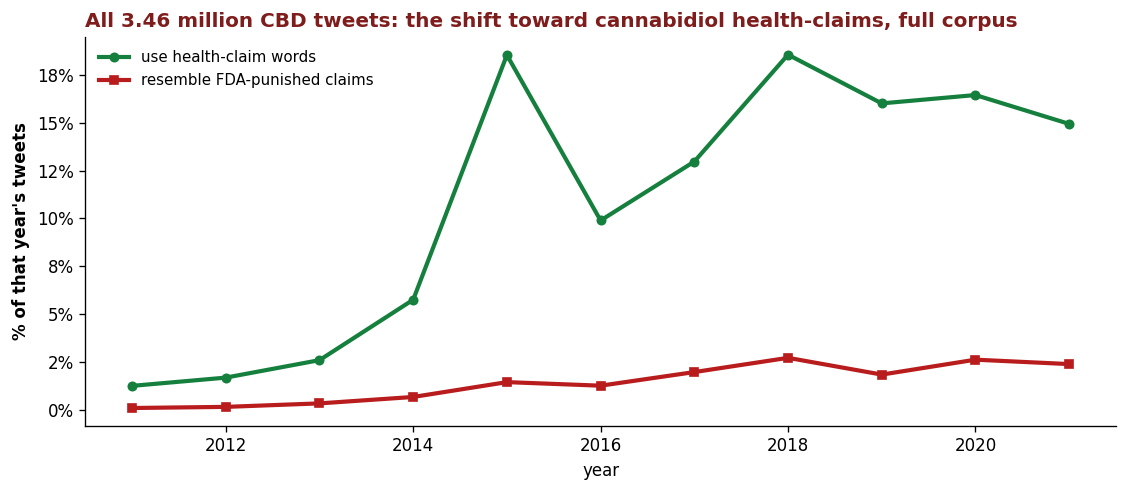

In [12]:
# the SAME §12 meter, applied to the ENTIRE corpus (precomputed: scripts/full_corpus_summary.py)
fc = pd.read_parquet(D / "full_corpus_resemblance.parquet")
N = len(fc); n_match = int(fc.matched.sum())
assert N == 3457986                                                                # lock: the whole corpus, not a sample
by = fc.groupby(fc.year.astype("Int64")).agg(health=("health", "mean"), matched=("matched", "mean")) * 100
print(f"FULL corpus: {N:,} tweets — no sampling")
print(f"  use health-claim language       : {100*fc.health.mean():.1f}% overall  (rises {by.health.iloc[0]:.0f}% → {by.health.max():.0f}% across the decade)")
print(f"  resemble the FDA fraud register  : {n_match:,} tweets  ({100*fc.matched.mean():.1f}% overall)")
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(by.index.astype(int), by.health, "-o", color=GREEN, lw=2.5, ms=5, label="use health-claim words")
ax.plot(by.index.astype(int), by.matched, "-s", color=RED, lw=2.5, ms=5, label="resemble FDA-punished claims")
ax.set_ylabel("% of that year's tweets", fontweight="bold"); ax.set_xlabel("year"); ax.yaxis.set_major_formatter(pct)
ax.set_title(f"All {N/1e6:.2f} million CBD tweets: the shift toward cannabidiol health-claims, full corpus", color=DARK, loc="left")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> Run over the <b>entire 3.46-million-tweet corpus</b>, both signals — health-claim language and resemblance to the FDA fraud register — climb together as cannabidiol displaces the old <i>Central Business District</i> sense. <b>Same story the sample told, now with no asterisk.</b> Two honest caveats: (1) this rise is a <b>topic shift</b> (more cannabidiol over time), <i>not</i> cannabidiol claims getting more fraud-shaped — <i>within</i> cannabidiol tweets the rate is flat (the early-warning lesson above); and (2) at the noisy <i>tweet</i> level the <i>absolute</i> resemblance rate is modest — most tweets aren't claims — so trust the <b>trend</b> and <b>raw volume</b>, not any single headline percentage.</div>

## A second anchor: does this generalize? (COVID)

One product is **n = 1** — and a fair reviewer will say exactly that. So here is a *completely different* episode: **COVID-19**. In 2020 the FDA mailed a flood of warning letters to sellers claiming their products *prevent or cure* coronavirus. The test: build a fraud register from **only pre-COVID, non-COVID, and non-CBD** products — fraud the regulator punished *before the disease even existed, and entirely unrelated to our first case* — and ask whether it recognizes COVID-cure claims. (Excluding CBD is what makes this a **genuinely independent** second anchor, not a re-test on overlapping data.)

This is a *harder, different* test than CBD, on purpose. CBD was a brand-**new product** with genuinely new claim-shapes. COVID was a brand-**new disease** wearing **old claim-shapes** — the same *"prevents / cures"* grammar with one noun swapped. If the old register still recognizes it, calibration-transfer isn't a CBD-specific fluke.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> It's the same con with a new headline. "Cures cancer" becomes "kills the coronavirus"; the essential-oil "antiviral" pitch written in 2014 is dusted off for 2020. The disease changes; the patter doesn't.</div>

register: 7,131 pre-COVID non-COVID fraud claims  |  COVID-cure claims tested: 1,247
recognized by the OLD register:  COVID 34%  |  legit medicine 5% (control)  |  unrelated 0%   ->  7x


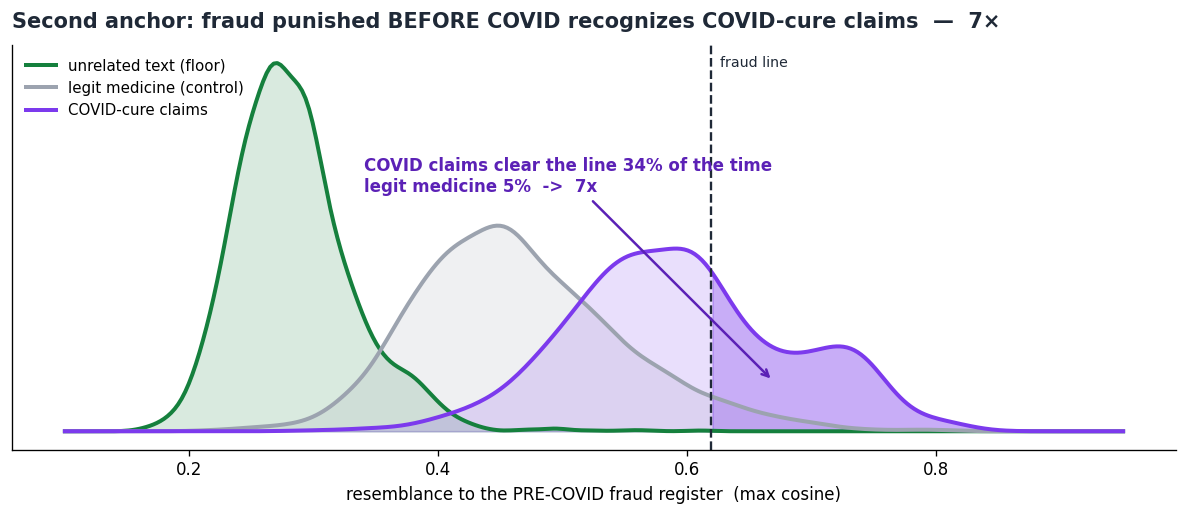

the NEW COVID-cure claim,"the OLDER, pre-COVID bust it rhymes with",match
“Natural Antiviral for Covid-19 with Essential Oils” (2022),"“Many Essential Oils are highly Anti-viral.” — Doterra International , 2014",0.800000
"“products are intended to mitigate, prevent, treat, diagnose, or cure COVID-19” (2020)","“your products are intended for use in the diagnosis, cure,” — Herbal Doctor Remedies, 2019",0.770000
“A potent antiviral for Covid.” (2021),"“an antiviral drug” — Icerx, 2018",0.770000
"“for use in the mitigation, prevention, treatment, diagnosis, or cure of COVID-19.” (2021)","“intended for use in the cure, mitigation, treatment, or pr” — , 2018",0.750000
"“these products are intended to mitigate, prevent, treat, diagnose, or cure COVID-19” (2020)","“your products are intended for use in the diagnosis, cure,” — Herbal Doctor Remedies, 2019",0.750000


In [13]:
# SECOND ANCHOR: does a register of PRE-COVID, NON-COVID fraud recognize COVID-cure claims?
from scipy.stats import gaussian_kde
isCOVID = C.claim_text.str.contains(r"covid|coronavirus|sars-cov|\bards\b", case=False, na=False)
isCBDc = C.claim_text.str.contains(r"\bcbd\b|cannabidiol|hemp", case=False, na=False) | (C.source == "cbd")  # exclude CBD too
Rc = ((C.year <= 2019) & (~isCOVID) & (~isCBDc)).to_numpy(); REc = CE[Rc]           # BEFORE COVID, non-COVID AND non-CBD -> 2nd anchor independent of the 1st
nearc = lambda X: np.concatenate([(X[i:i+4000] @ REc.T).max(1) for i in range(0, len(X), 4000)])
psc = nearc(L2(np.load(D / "pubmed_background_embeddings.npy"))); Tc = float(np.percentile(psc, 95))   # legit medicine = control
dsc = nearc(L2(np.load(D / "crec_drone_embeddings.npy")))                                              # unrelated = floor
covm = (isCOVID & (C.year >= 2020)).to_numpy(); covid = C[covm].reset_index(drop=True); csim = nearc(CE[covm])
ratec, pmc, drc = (csim > Tc).mean(), (psc > Tc).mean(), (dsc > Tc).mean(); liftc = ratec / pmc
assert round(liftc) == 7 and REc.shape[0] > 5000                                    # lock the ~7x second-anchor result (CBD-excluded, independent)
print(f"register: {REc.shape[0]:,} pre-COVID non-COVID fraud claims  |  COVID-cure claims tested: {int(covm.sum()):,}")
print(f"recognized by the OLD register:  COVID {100*ratec:.0f}%  |  legit medicine {100*pmc:.0f}% (control)  |  unrelated {100*drc:.0f}%   ->  {liftc:.0f}x")
PUR = "#7c3aed"
fig, ax = plt.subplots(figsize=(10, 4.4)); xx = np.linspace(0.1, 0.95, 300); ck = gaussian_kde(csim)
for v, c, lab in [(dsc, GREEN, "unrelated text (floor)"), (psc, GREY, "legit medicine (control)"), (csim, PUR, "COVID-cure claims")]:
    yk = gaussian_kde(v)(xx); ax.fill_between(xx, yk, color=c, alpha=0.16); ax.plot(xx, yk, color=c, lw=2.4, label=lab)
ytop = ax.get_ylim()[1]; ax.axvline(Tc, ls="--", lw=1.4, color=INK); ax.text(Tc, ytop*0.97, "  fraud line", fontsize=8.5, color=INK, va="top")
xf = xx[xx >= Tc]; ax.fill_between(xf, ck(xf), color=PUR, alpha=0.30)
ax.annotate(f"COVID claims clear the line {100*ratec:.0f}% of the time\nlegit medicine {100*pmc:.0f}%  ->  {liftc:.0f}x",
    xy=(float(Tc+0.05), float(ck(np.array([Tc+0.05]))[0])*0.6), xytext=(0.34, ytop*0.62),
    fontsize=10, fontweight="bold", color="#5b21b6", arrowprops=dict(arrowstyle="->", color="#5b21b6", lw=1.5))
ax.set_xlabel("resemblance to the PRE-COVID fraud register  (max cosine)", fontsize=10); ax.set_yticks([]); ax.legend(frameon=False, fontsize=9, loc="upper left")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
ax.set_title(f"Second anchor: fraud punished BEFORE COVID recognizes COVID-cure claims  —  {liftc:.0f}×", fontsize=12.5, fontweight="bold", color=INK, loc="left", pad=10)
plt.tight_layout(); plt.show()
# the rhymes: each NEW COVID claim beside the OLDER, pre-COVID bust it most resembles
Rdfc = C[Rc].reset_index(drop=True); Sc = CE[covm] @ REc.T; nnc = Sc.argmax(1)
cl = lambda s: " ".join(re.sub(r"\[sic\]", "", str(s)).split()).strip(chr(8220)+chr(8221)+chr(34)+chr(39)+" ")
rr = []; seen = set()
for i in np.argsort(-Sc.max(1)):
    cc = cl(covid.claim_text[i])
    if not (25 < len(cc) < 84) or cc[:24] in seen: continue
    seen.add(cc[:24]); pp = Rdfc.iloc[nnc[i]]
    rr.append({"the NEW COVID-cure claim": f"“{cc}”  ({int(covid.year[i])})",
               "the OLDER, pre-COVID bust it rhymes with": f"“{cl(pp.claim_text)[:58]}”  —  {str(pp.firm)[:22].title()}, {int(pp.year)}",
               "match": round(float(Sc[i, nnc[i]]), 2)})
    if len(rr) >= 5: break
display(pd.DataFrame(rr).style.hide(axis="index").background_gradient(subset=["match"], cmap="Purples", vmin=0.5, vmax=1.0)
        .set_properties(**{"text-align": "left", "font-size": "10pt", "padding": "5px 11px"})
        .set_properties(subset=["the NEW COVID-cure claim"], **{"color": "#5b21b6", "font-weight": "bold"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10pt"), ("padding", "5px 11px")]}]))

<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait, what? — Wait — earlier you showed COVID did <i>not</i> trip the novelty alarm. Now it's strongly recognized as fraud-shaped. Which is it?</b><br> <b>Both — and that's the whole point.</b> COVID fraud <b>recycled the old grammar</b> (the essential-oil "antiviral" pitch, the boilerplate "intended to prevent/treat"), just aimed at a new disease. To the <b>novelty</b> detector that grammar looks <i>familiar</i>, so it doesn't spike. To the <b>register</b>, that same familiarity is exactly what gets it <i>recognized</i> — ~7× the control. <b>New-disease / old-grammar reads as un-novel to the catcher and very familiar to the register</b> — two readings of one fact, and they agree.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> A fraud register built <b>entirely from pre-COVID, non-COVID, and non-CBD products</b> recognizes COVID-cure claims <b>~7×</b> more than legitimate medicine — a transfer of the same order as CBD's <b>9×</b>, and from a register that shares <i>no claims</i> with the first case. Two mechanistically <i>different</i> episodes — a new <b>product</b> (CBD) and a new <b>disease</b> (COVID) — both recognized by the regulator's older back-catalogue. That puts the calibration-transfer claim on <b>two genuinely independent anchors, not one</b>. The same honest bound still holds: it sees <i>therapeutic-claim-shaped</i>, not <i>false</i>.</div>

## Zoom out: the whole decade, and do the two bouncers agree?

CBD was one product. Run **both** detectors on the entire 12-year, all-products library and check: did the FDA's focus drift — and do two methods built on different assumptions tell the same story? (If they do, that's a *cross-check* that the drift is real — convergent validity, not proof of anything new.)

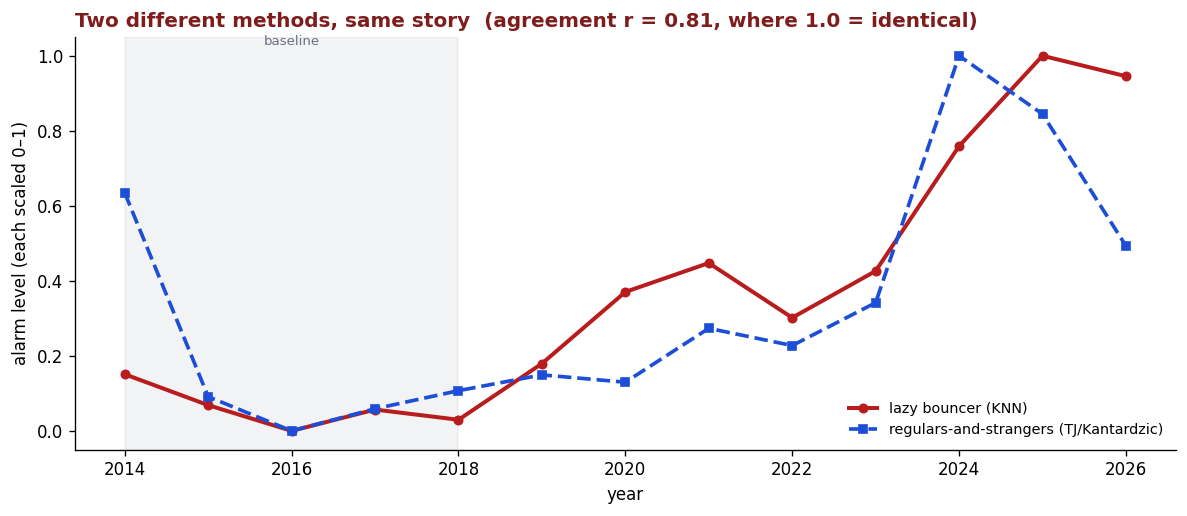

both rise into a 2024–26 surge | agreement r = 0.81


In [14]:
# both detectors on the full library + do they agree?
M = sd.table[["period", "margin_density"]]; K = kn.table[["period", "novelty_density"]]
J = K.merge(M, on="period").sort_values("period").reset_index(drop=True); mon = ~J.period.isin(REF)
r = float(np.corrcoef(J.novelty_density[mon], J.margin_density[mon])[0, 1])
assert r > 0.7                                                                     # lock "they agree"
nrm = lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9)
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.axvspan(min(REF), max(REF), color=GREY, alpha=0.12); ax.text(np.mean(REF), 1.03, "baseline", ha="center", fontsize=8, color=MUTE)
ax.plot(J.period, nrm(J.novelty_density), "-o", color=RED, lw=2.4, ms=5, label="lazy bouncer (KNN)")
ax.plot(J.period, nrm(J.margin_density), "--s", color=BLUE, lw=2.2, ms=5, label="regulars-and-strangers (TJ/Kantardzic)")
ax.set_title(f"Two different methods, same story  (agreement r = {r:.2f}, where 1.0 = identical)", color=DARK, loc="left")
ax.set_xlabel("year"); ax.set_ylabel("alarm level (each scaled 0–1)"); ax.legend(frameon=False, fontsize=8.6)
plt.tight_layout(); plt.show()
print(f"both rise into a 2024–26 surge | agreement r = {r:.2f}")

**How to read this.** Both detectors are rescaled to a 0–1 alarm level and drawn together; if two mechanically different methods trace the same shape, they're telling the same story. They do — both climb into a **2024–26 surge** — at a correlation of **r ≈ 0.8**. Read that as a *cross-check*, not a discovery: agreement makes a single-method artifact unlikely, but it does not, on its own, prove the drift is "real" out in the world.

<div style="border-left:4px solid #6b7280;background:#f3f4f6;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Where's the agreement number from, and is 0.8 good?</b>  It's the correlation between the two methods' year-by-year alarm levels: <b>1.0</b> = move in lockstep, <b>0</b> = unrelated. Here it's ~<b>0.8</b>. For honesty, the full picture: on clean test data the two agree at <b>0.99</b>; on CBD alone <b>0.91</b>; on this messy 12-year all-products pile <b>~0.8</b>. Agreement drops as the data gets messier — exactly what you'd expect, and a sign the number is real, not staged.</div>

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> Don\'t over-read the correlation. <b>(1) Agreement is not correctness</b> — two methods <i>can</i> share a blind spot and be wrong together; convergence lowers the odds of a fluke, it does not guarantee truth. <b>(2) The curves are min–max rescaled and there are only ~10 yearly points</b>, so both the eye and the number <i>overstate</i> how "identical" they look. <b>(3) r is a summary, not a per-year promise</b> — the two can still disagree in any single year. Agreement is <b>hygiene</b> — the cheapest honesty check there is — not the finding itself.</div>

<div style="border-left:4px solid #b91c1c;background:#fef2f2;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Remember.</b> Two methods built on opposite assumptions both say the FDA's focus broadened and surged in 2024–26. They agree most on clean data and less on messy data — which is honest, not suspicious.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> Across the full 12-year, all-products library, <b>both detectors independently</b> say the FDA's focus broadened and surged in 2024–26, and they agree more on clean data than messy data — exactly the honest pattern you'd want to see. Use that agreement as a <b>robustness check on the workflow</b>; it earns trust, but it is a check, not the contribution.</div>

## The handoff: one detector *catches* the surge, the other *names* it

The agreement plot shows both detectors see the 2024–26 surge. But they don't do the *same job* — and this is the clearest way to see why we keep both, instead of picking a winner. Run them on the full library and ask each one what it can actually tell you about that surge.

<div style="border-left:4px solid #b45309;background:#fffbeb;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Picture it.</b> A smoke alarm and a fire investigator aren't rivals. The alarm is cheap, instant, and screams the moment something's wrong — but it can't tell you what burned. The investigator is slower and pricier, but walks out with a cause. You want both on the payroll.</div>

/Users/jasonturner/Projects/pycorpdiff/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


knn flagged 1,413 novel claims in 2024-26 (left)  ->  sense_drift resolves them into 4 named senses (right)


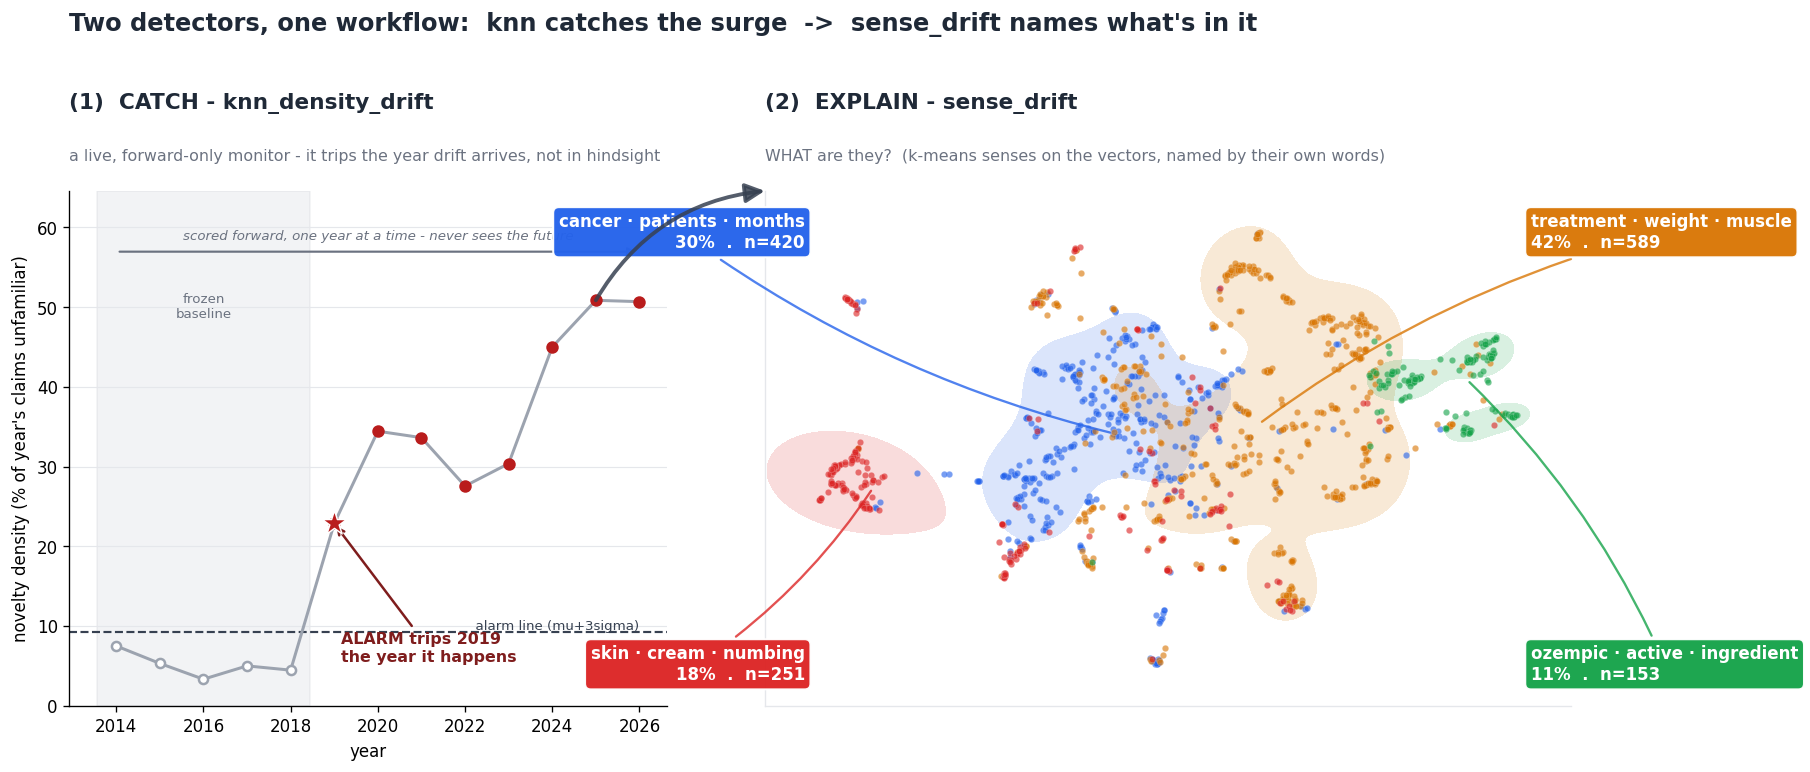

In [15]:
# THE HANDOFF as one figure: knn CATCHES the surge over time (left) -> sense_drift NAMES what's in it (right)
import umap
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde
from collections import Counter
from matplotlib.patches import ConnectionPatch
RR = CE[C.year.isin(REF).to_numpy()]                                          # knn_density_drift reference-mode novelty (its own formula)
def _kn(X, S, kk=10):
    o = np.empty(len(X), np.float32)
    for i in range(0, len(X), 4000):
        s = X[i:i+4000] @ S.T; o[i:i+len(s)] = 1 - np.sort(s, 1)[:, -kk:].mean(1)
    return o
_nv = _kn(CE, RR); _th = np.percentile(_nv[C.year.isin(REF).to_numpy()], 95)
yrs2 = sorted(int(y) for y in C.year.dropna().unique())
dens = {y: float((_nv[(C.year == y).to_numpy()] > _th).mean() * 100) for y in yrs2}
surge = ((C.year >= 2024) & (_nv > _th)).to_numpy(); E = CE[surge]; tx = C.claim_text[surge].reset_index(drop=True)
cl = lambda s: " ".join(re.sub(r"\[sic\]", "", str(s)).split()).strip(chr(8220)+chr(8221)+chr(34)+chr(39)+" ")
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(E)                   # sense_drift: cluster the surge on the vectors
PALETTE = ["#2563eb", "#d97706", "#16a34a", "#dc2626"]
STOPW = set("the a an and or of to in for with is are be this that on you your it as we our will can may have has not no by from at use used its their them they product products also more most than then over out off do does help helps support intended treat treats claim claims drug drugs fda".split())
nm = {}; col = {}
for k in range(4):                                                            # name each sense by ITS OWN top words (no hand-authored labels)
    ix = np.where(km.labels_ == k)[0]; blob = " ".join(cl(t).lower() for t in tx[ix])
    w = [t for t in re.findall(r"[a-z][a-z-]{3,}", blob) if t not in STOPW and not t.endswith("-")]
    nm[k] = " · ".join(x for x, _ in Counter(w).most_common(3)); col[k] = PALETTE[k]
XY = umap.UMAP(n_neighbors=20, min_dist=0.0, spread=1.2, metric="cosine", random_state=42).fit_transform(E)
print(f"knn flagged {int(surge.sum()):,} novel claims in 2024-26 (left)  ->  sense_drift resolves them into 4 named senses (right)")

INK, MUTE, GRID = "#1f2937", "#6b7280", "#e5e7eb"
fig = plt.figure(figsize=(13.6, 6.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.14, left=0.065, right=0.985, top=0.76, bottom=0.10)
ax1 = fig.add_subplot(gs[0]); xs = np.array(yrs2); ys = np.array([dens[y] for y in yrs2])
by = np.array([dens[y] for y in REF]); thr = by.mean() + 3*by.std()           # alarm line from the FROZEN baseline only
above = ys > thr; first = int(xs[above][0])
ax1.axvspan(min(REF)-0.45, max(REF)+0.45, color="#9ca3af", alpha=0.12)         # frozen baseline window
ax1.text(np.mean(REF), max(ys)*1.02, "frozen\nbaseline", ha="center", va="top", fontsize=8, color=MUTE)
ax1.plot(xs, ys, color="#9ca3af", lw=1.8, zorder=2)                            # the live novelty stream
ax1.axhline(thr, ls="--", lw=1.3, color="#374151", zorder=1)
ax1.text(xs[-1], thr, "  alarm line (mu+3sigma)", ha="right", va="bottom", fontsize=8, color="#374151")
ax1.scatter(xs[~above], ys[~above], s=30, facecolor="white", edgecolor="#9ca3af", lw=1.5, zorder=3)   # normal: hollow
ax1.scatter(xs[above], ys[above], s=42, color="#b91c1c", zorder=4)                                     # ALARM: solid red
ax1.scatter([first], [dens[first]], s=240, marker="*", color="#b91c1c", edgecolor="white", lw=0.9, zorder=5)
ax1.annotate(f"ALARM trips {first}\nthe year it happens", xy=(first, dens[first]), xytext=(first+0.15, dens[first]-max(ys)*0.34),
    fontsize=9.5, fontweight="bold", color="#7f1d1d", ha="left", arrowprops=dict(arrowstyle="->", color="#7f1d1d", lw=1.5))
ax1.annotate("", xy=(xs[-1], max(ys)*1.12), xytext=(min(REF), max(ys)*1.12), arrowprops=dict(arrowstyle="-|>", color=MUTE, lw=1.3))
ax1.text((min(REF)+xs[-1])/2, max(ys)*1.15, "scored forward, one year at a time - never sees the future", ha="center", fontsize=8, color=MUTE, style="italic")
ax1.text(0, 1.16, "(1)  CATCH - knn_density_drift", transform=ax1.transAxes, fontsize=13, fontweight="bold", color=INK)
ax1.text(0, 1.06, "a live, forward-only monitor - it trips the year drift arrives, not in hindsight", transform=ax1.transAxes, fontsize=9.5, color=MUTE)
ax1.set_ylabel("novelty density (% of year's claims unfamiliar)", fontsize=10); ax1.set_xlabel("year", fontsize=10)
for s in ["top", "right"]: ax1.spines[s].set_visible(False)
ax1.grid(axis="y", color=GRID, lw=0.7); ax1.set_ylim(0, max(ys)*1.27)
ax2 = fig.add_subplot(gs[1])
gx = np.linspace(XY[:,0].min()-1, XY[:,0].max()+1, 180); gy = np.linspace(XY[:,1].min()-1, XY[:,1].max()+1, 180)
GX, GY = np.meshgrid(gx, gy); grid = np.vstack([GX.ravel(), GY.ravel()])
for k in range(4):
    m = km.labels_ == k
    try:
        Z = gaussian_kde(XY[m].T)(grid).reshape(GX.shape)
        ax2.contourf(GX, GY, Z, levels=[Z.max()*0.45, Z.max()], colors=[col[k]], alpha=0.16, zorder=1)
    except Exception:
        pass
for k in range(4):
    m = km.labels_ == k; ax2.scatter(XY[m,0], XY[m,1], s=15, c=col[k], alpha=0.62, edgecolors="white", linewidths=0.15, zorder=2)
xr = (XY[:,0].min(), XY[:,0].max()); yg = (XY[:,1].min(), XY[:,1].max())
anch = {0:(xr[0]-(xr[1]-xr[0])*0.02, yg[1]), 1:(xr[1]+(xr[1]-xr[0])*0.02, yg[1]), 2:(xr[1]+(xr[1]-xr[0])*0.02, yg[0]), 3:(xr[0]-(xr[1]-xr[0])*0.02, yg[0])}
hal = {0:"right", 1:"left", 2:"left", 3:"right"}
for k in range(4):
    m = km.labels_ == k; cx, cy = np.median(XY[m,0]), np.median(XY[m,1]); axx, ayy = anch[k]
    ax2.annotate(f"{nm[k]}\n{100*m.mean():.0f}%  .  n={int(m.sum())}", xy=(cx, cy), xytext=(axx, ayy), ha=hal[k], va="center",
        fontsize=10, fontweight="bold", color="white", zorder=6,
        bbox=dict(boxstyle="round,pad=0.34", fc=col[k], ec="white", lw=1.2, alpha=0.97),
        arrowprops=dict(arrowstyle="-", color=col[k], lw=1.4, alpha=0.8, connectionstyle="arc3,rad=0.1"))
ax2.text(0, 1.16, "(2)  EXPLAIN - sense_drift", transform=ax2.transAxes, fontsize=13, fontweight="bold", color=INK)
ax2.text(0, 1.06, "WHAT are they?  (k-means senses on the vectors, named by their own words)", transform=ax2.transAxes, fontsize=9.5, color=MUTE)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.margins(0.16)
for s in ax2.spines.values(): s.set_edgecolor(GRID)
con = ConnectionPatch(xyA=(2025, dens[2025]), coordsA=ax1.transData, xyB=(0.0, 1.0), coordsB=ax2.transAxes,
    arrowstyle="-|>", lw=2.3, color="#374151", connectionstyle="arc3,rad=-0.25", mutation_scale=24, alpha=0.85)
fig.add_artist(con)
fig.suptitle("Two detectors, one workflow:  knn catches the surge  ->  sense_drift names what's in it",
    fontsize=14.5, fontweight="bold", color=INK, x=0.065, ha="left", y=0.99)
plt.show()

**The alarm log — what tripped each red dot.** The figure shows *when* the monitor fired and zooms in on the 2024–26 surge. This table is its companion: it walks **every alarm year** and reads out the *rising category* among that year's flagged claims — the bullshit frontier moving in real time. **▲** marks a genuinely rising category; *"mixed"* flags a diffuse, transitional year (honest — not every year has one clean story).

In [16]:
# ALARM LOG: each red-dot year -> the rising category among that year's KNN-flagged novel claims (+ a real example)
from collections import Counter
THEMES = [("COVID-19 cures", r"covid|coronavirus|sars-cov|\bards\b"),
          ("GLP-1 / weight-loss drugs", r"ozempic|wegovy|semaglutide|tirzepatide|mounjaro|zepbound|retatrutide|\bglp\b|weight[- ]?loss"),
          ("topical numbing creams", r"numb|tattoo|tktx|lidocaine|\bblt\b"),
          ("delta-8 & novel cannabinoids", r"delta-?8|delta-?9|thc-?o|\bhhc\b|cbg|cbda"),
          ("controlled-substance sales", r"oxycodone|adderall|methylphenidate|hydrocodone|tramadol|opioid|xanax"),
          ("CBD goes medical", r"\bcbd\b|cannabidiol|hemp")]
_thm = lambda t: next((nm for nm, p in THEMES if re.search(p, " ".join(str(t).split()).lower())), "(generic supplement claims)")
_alarm = [y for y in yrs2 if dens[y] > thr]; _gl = Counter()
for y in _alarm:
    mm = ((C.year == y) & (_nv > _th)).to_numpy(); _gl.update(_thm(t) for t in C.claim_text[mm])
_G = sum(_gl.values()); _rows = []
for y in _alarm:
    mm = ((C.year == y) & (_nv > _th)).to_numpy(); cnt = Counter(_thm(t) for t in C.claim_text[mm]); n = sum(cnt.values())
    name, c0 = [(t, c) for t, c in cnt.most_common() if t != "(generic supplement claims)"][0]
    share = 100*c0/n; lift = (c0/n)/(_gl[name]/_G + 1e-9)
    head = (f"▲ {name}" if (lift >= 1.3 and share >= 6) else f"mixed — led by {name}")
    ex = next((" ".join(re.sub(r"\[sic\]", "", str(t)).split()).strip(chr(8220)+chr(8221)+chr(34)+chr(39)+" ")
               for t in C.claim_text[mm] if _thm(t) == name and 25 < len(str(t)) < 95), "")[:82]
    _rows.append({"year": y, "alarm (novelty %)": round(dens[y]), "what KNN flagged surging": f"{head}  ({share:.0f}% of new claims)", "a representative new claim that year": f"“{ex}”"})
LOG = pd.DataFrame(_rows)
display(LOG.style.hide(axis="index")
        .background_gradient(subset=["alarm (novelty %)"], cmap="Reds", vmin=0, vmax=60)
        .set_properties(**{"text-align": "left", "font-size": "10.5pt", "padding": "4px 10px"})
        .set_properties(subset=["what KNN flagged surging"], **{"font-weight": "bold", "color": "#7f1d1d"})
        .set_properties(subset=["a representative new claim that year"], **{"font-style": "italic", "color": "#374151"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10.5pt"), ("padding", "4px 10px")]}]))

year,alarm (novelty %),what KNN flagged surging,a representative new claim that year
2019,23,mixed — led by CBD goes medical (2% of new claims),“And so does the LEGAL cousin Hemp CBD!”
2020,34,▲ COVID-19 cures (30% of new claims),“Fight off Coronavirus with NoronaPak”
2021,34,▲ COVID-19 cures (22% of new claims),“Immunoral: a new immune-based therapy against the COVID-19 pathogen”
2022,28,mixed — led by COVID-19 cures (12% of new claims),“Fight against disease Studies show zinc fights the replication of diseases like CO”
2023,30,mixed — led by COVID-19 cures (3% of new claims),"“Our CBDefense 2000, anti-covid formula, is Now Available. . . Use Code: DEFENSE”"
2024,45,▲ GLP-1 / weight-loss drugs (11% of new claims),“Retatrutide is a new medicine that helps control blood sugar and supports weight l”
2025,51,▲ GLP-1 / weight-loss drugs (13% of new claims),“Same active ingredient in Mounjaro and Zepbound”
2026,51,▲ GLP-1 / weight-loss drugs (31% of new claims),“Ozempic – Weight Loss Supplement.”


<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait — isn't sense_drift just keyword-matching to get those labels?</b><br> No. Both the 2-D layout <i>and</i> the grouping are computed <b>on the 384-number vectors alone</b> — k-means on meaning, zero words involved. Each region is only <i>labeled</i> afterward, by reading off that cluster's own most-frequent words and attaching the plain-English theme they point to. The kicker that it's <i>real</i>: these senses line up exactly with what the FDA actually escalated in 2024–26 — the <b>compounded-semaglutide (GLP-1) boom</b> and <b>unapproved tattoo-numbing creams</b>.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> The partnership, made literal. <code>knn_density_drift</code> is the <b>smoke alarm</b> — it caught the 2024–26 surge instantly, streaming, no re-fit — but could only hand over an <i>unlabeled</i> pile. <code>sense_drift</code> is the <b>detective</b> — handed that same pile, it resolved it into named senses: the <b>GLP-1 weight-loss wave</b>, <b>compounded Ozempic knockoffs</b>, and <b>cosmetic numbing creams</b>. <b>Catch with one, explain with the other</b> — neither does the other's job, which is exactly why you run both.</div>

## Watch it happen: the monitor running, frame by frame

The handoff above is a single snapshot — but the whole pitch is that this runs **live**, so here it is as a time-lapse. **Each frame is one year.** The cloud is the claim-space; the little line in the corner is the novelty alarm, drawn forward-only. Two rules keep this honest instead of a highlight reel:

- **No look-ahead.** The senses and the alarm line are *frozen on the early baseline window* and never updated — every later year is scored against that frozen past. The monitor never sees the future it is about to be tested on.
- **The map is fixed.** The 2-D projection is fit **once** and reused for every frame, so when claims pile into empty space it is *real* drift, not the layout reshuffling. (Re-fitting per frame is the classic way these animations lie.)

Watch the grey baseline sit still while brand-new territory erupts around it — **caught** by `knn_density_drift` the year it lands, **named** by `sense_drift` from its own words.

### Stream 1 — the FDA enforcement frontier, 2014 → 2026

Frozen on **2014–18**. Press play: quiet for years, then **2019** the alarm trips; **2020** a *COVID-cure* island erupts; and by **2024–26** the frontier has moved again to **GLP-1 / Ozempic knockoffs** and **numbing creams** — each caught as novel, each named by its own vocabulary.

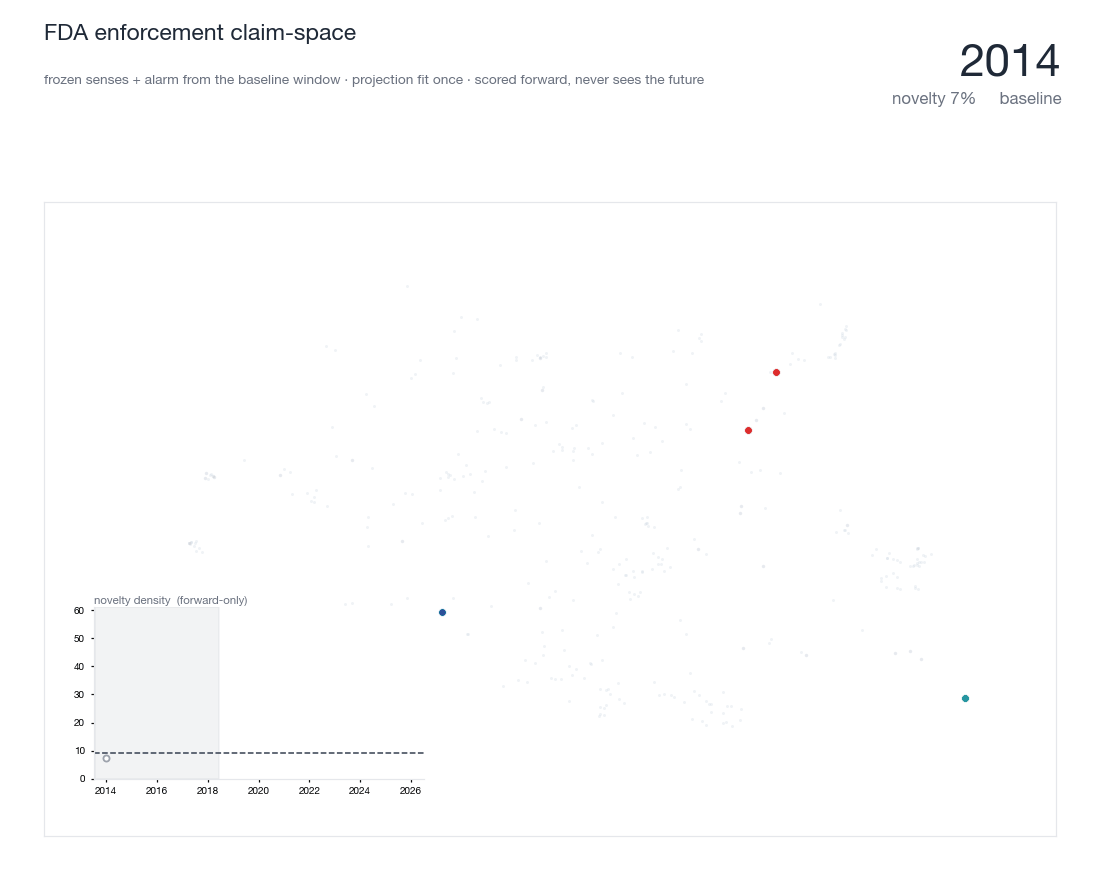

In [17]:
# time-lapse: the frozen monitor reacting to the FDA claim-space, one year per frame (precomputed in scripts/realtime_monitor.py)
import base64
from IPython.display import Image as IPImage, display
SC = next(p for p in [Path("scripts"), Path("../scripts")] if (p / "rtm_fda_frontier.gif").exists())
def show_gif(name):                                  # dual mime: image/gif (GitHub/nbviewer) + <img> fallback (static HTML)
    b = base64.b64encode((SC / name).read_bytes()).decode()
    display({"image/gif": b, "text/html": f'<img src="data:image/gif;base64,{b}" style="max-width:100%;height:auto;"/>'}, raw=True)
show_gif("rtm_fda_frontier.gif")

**The monitor log — the same time-lapse as a play-by-play.** One row per year: how much of it read *novel*, whether the alarm tripped, the change-type `sense_drift` assigns, the rising sense, and the words that named it. The system catching *and* explaining, line by line.

In [18]:
rt = pd.read_parquet(D / "rtm_fda_frontier_table.parquet").copy()
rt["alarm"] = rt["alarm"].map({True: "● ALARM", False: ""})
rt = rt.rename(columns={"new": "new claims", "novelty_pct": "novelty %", "signal": "TJ signal", "rising_sense": "rising sense (KNN→TJ)", "words": "its own words"})
display(rt.style.hide(axis="index")
        .background_gradient(subset=["novelty %"], cmap="Reds", vmin=0, vmax=55)
        .set_properties(**{"text-align": "left", "font-size": "10pt", "padding": "3px 9px"})
        .set_properties(subset=["rising sense (KNN→TJ)"], **{"font-weight": "bold", "color": "#7f1d1d"})
        .set_properties(subset=["its own words"], **{"font-style": "italic", "color": "#374151"})
        .set_properties(subset=["alarm"], **{"font-weight": "bold", "color": "#b91c1c"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10pt"), ("padding", "3px 9px")]}]))

year,new claims,novelty %,alarm,TJ signal,rising sense (KNN→TJ),its own words
2014,1001,7.500000,,—,—,"laser, better, ingredient, treatment, weeks"
2015,962,5.300000,,—,—,"heart, including, blood, cells, healthy"
2016,1295,3.300000,,—,—,"acid, disease, night, heart, which"
2017,1884,5.000000,,—,—,"started, blood, years, pressure, been"
2018,1055,4.500000,,—,—,"problems, years, blood, such, text"
2019,1794,22.900000,● ALARM,broadening,(diffuse),"treatment, pain, disease, cancer, after"
2020,2370,34.400000,● ALARM,broadening,COVID-cure claims,"coronavirus, virus, treatment, against, body"
2021,2418,33.600000,● ALARM,broadening,COVID-cure claims,"been, against, coronavirus, natural, blood"
2022,1695,27.600000,● ALARM,broadening,COVID-cure claims,"treatment, blood, body, pain, effective"
2023,1100,30.400000,● ALARM,broadening,(diffuse),"molluscum, treatment, energy, natural, body"


**Same story, four stills** (for print, and for studying a single frame):

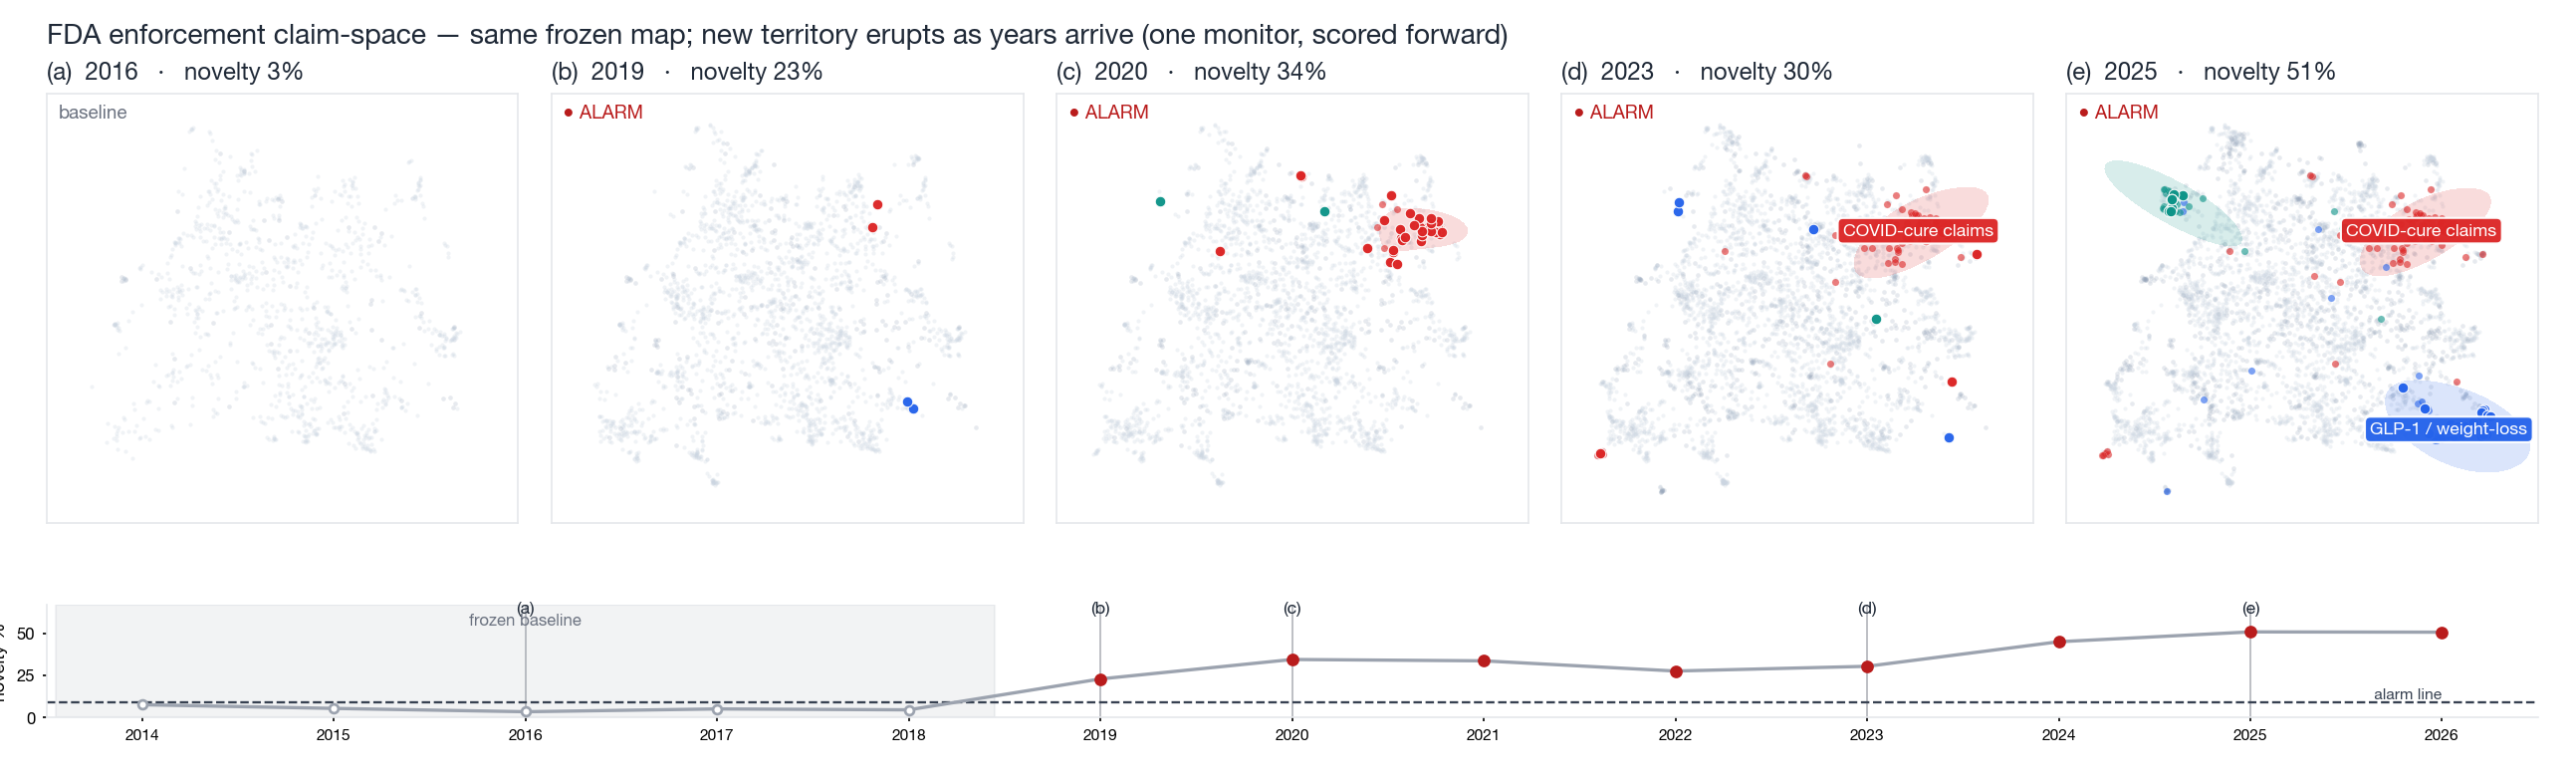

In [19]:
IPImage(filename=str(SC / "rtm_fda_frontier_filmstrip.png"))

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> A monitor frozen in 2018 sat quiet, then tripped in <b>2019</b> and watched the fraud frontier march past it — <b>COVID-cure</b> claims in 2020, <b>GLP-1 / Ozempic knockoffs</b> and <b>numbing creams</b> by 2025 — catching each as it arrived and naming it from its own words. Nothing here is hindsight: every score uses only the frozen past.</div>

### Stream 2 — the CBD tweet stream, 2011 → 2021 (the early warning)

Same machine, pointed at *public talk* instead of enforcement records, frozen on **2011–13**. The alarm trips in **2014** — the **hemp / CBD-product boom** erupting in real time, *years before* the FDA's 2019 crackdown — with the medical-claim territories (pain/wellness, serious-disease) growing in behind it. The early-warning promise, shown as it happens.

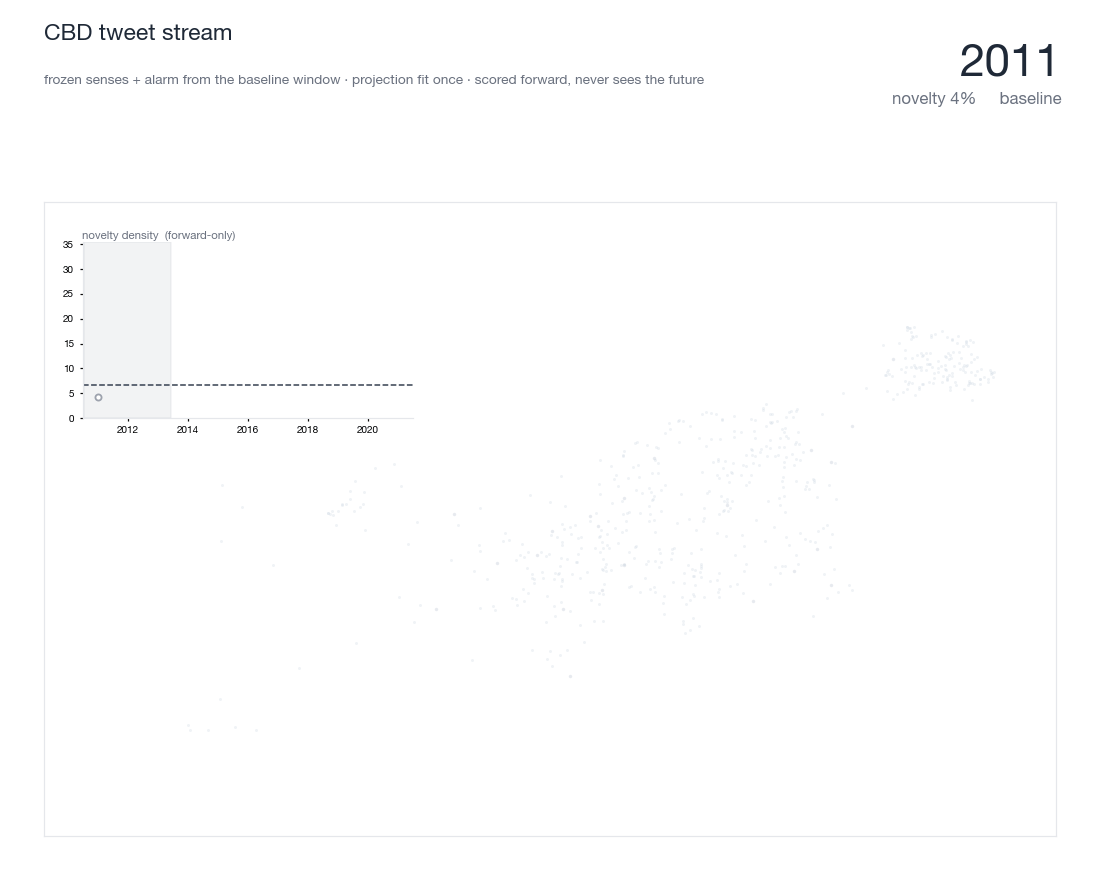

In [20]:
show_gif("rtm_cbd_tweets.gif")

In [21]:
rt = pd.read_parquet(D / "rtm_cbd_tweets_table.parquet").copy()
rt["alarm"] = rt["alarm"].map({True: "● ALARM", False: ""})
rt = rt.rename(columns={"new": "new tweets", "novelty_pct": "novelty %", "signal": "TJ signal", "rising_sense": "rising sense (KNN→TJ)", "words": "its own words"})
display(rt.style.hide(axis="index")
        .background_gradient(subset=["novelty %"], cmap="Reds", vmin=0, vmax=55)
        .set_properties(**{"text-align": "left", "font-size": "10pt", "padding": "3px 9px"})
        .set_properties(subset=["rising sense (KNN→TJ)"], **{"font-weight": "bold", "color": "#7f1d1d"})
        .set_properties(subset=["its own words"], **{"font-style": "italic", "color": "#374151"})
        .set_properties(subset=["alarm"], **{"font-weight": "bold", "color": "#b91c1c"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10pt"), ("padding", "3px 9px")]}]))

year,new tweets,novelty %,alarm,TJ signal,rising sense (KNN→TJ),its own words
2011,2995,4.200000,,—,—,"sydney, after, people, just, today"
2012,2995,5.400000,,—,—,"just, sydney, today, morning, like"
2013,2996,5.400000,,—,hemp / CBD-product boom,"today, been, after, about, just"
2014,2992,20.600000,● ALARM,broadening,hemp / CBD-product boom,"hemp, sydney, after, kannaway, rich"
2015,2999,15.900000,● ALARM,broadening,hemp / CBD-product boom,"hemp, marijuana, cannabis, hempoil, biofuel"
2016,2997,19.200000,● ALARM,broadening,hemp / CBD-product boom,"hemp, marijuana, cannabis, great, people"
2017,2999,20.000000,● ALARM,broadening,hemp / CBD-product boom,"cannabis, until, available, wild, marijuana"
2018,2990,23.800000,● ALARM,broadening,hemp / CBD-product boom,"hemp, cannabis, available, found, until"
2019,2997,18.900000,● ALARM,broadening,hemp / CBD-product boom,"cannabis, hemp, weed, marijuana, business"
2020,2982,29.500000,● ALARM,broadening,hemp / CBD-product boom,"cannabis, hemp, marijuana, business, weed"


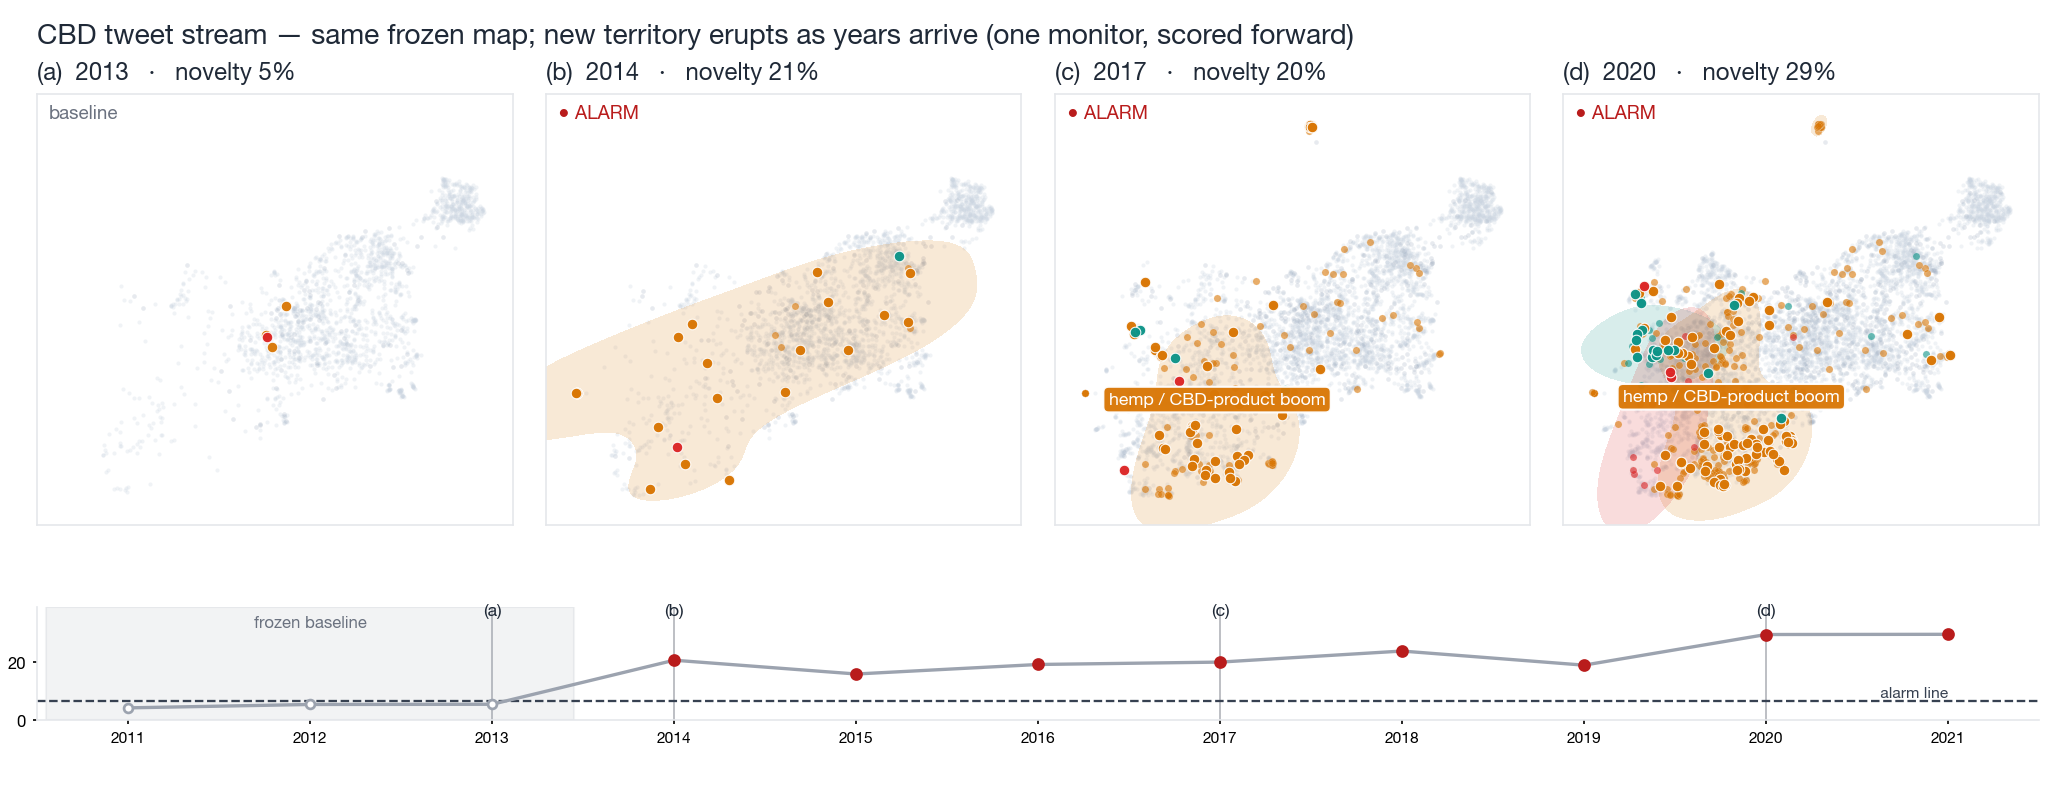

In [22]:
IPImage(filename=str(SC / "rtm_cbd_tweets_filmstrip.png"))

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> Frozen on 2011–13 and replayed forward, the same monitor trips in <b>2014</b> — the hemp/CBD-product boom, caught from public chatter alone, <b>~5 years before</b> the FDA's enforcement wave. On tweets the naming is noisier than on the FDA's tidy claims (tweets are messy) — honest, and exactly why the regulator's record is the better-calibrated anchor.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> <b>The system, live.</b> One frozen monitor, two streams: on the regulator's record it watches the fraud frontier march <b>CBD → COVID → GLP-1</b>; on public talk it trips <b>years ahead</b> of enforcement. Same two moves every single frame — <code>knn_density_drift</code> <b>catches</b>, <code>sense_drift</code> <b>names</b> — running forward, never peeking. Two detectors, one workflow, watched in real time.</div>

### So it catches *any* new topic? No — and the boundary is the interesting part

A fair worry about the "catcher": does it just scream every time a new word shows up? If so it would be useless — the news is always new. Watch what happens at the single most obvious "new topic" in the whole record: **COVID**, which dumped hundreds of fraud claims into the library in 2020.

In [23]:
# does the streaming detector spike when COVID fraud floods in (2020)?
kc = pcd.knn_density_drift(C, CE, "year", reference=REF, k=10, mode="cumulative", text_col="claim_text")  # streaming: novelty vs everything strictly earlier
covid_2020 = int(C.claim_text.str.contains(r"covid|coronavirus|sars-cov", case=False, na=False)[C.year.eq(2020)].sum())
nov_2020 = float(kc.table.loc[kc.table.period == 2020, "novelty_density"].iloc[0])
base = float(kc.table[(kc.table.period >= 2016) & (kc.table.period <= 2019)].novelty_density.mean())
assert nov_2020 < base                                                            # lock: COVID did NOT spike the detector
print(f"COVID-fraud claims arriving in 2020 : {covid_2020}")
print(f"streaming novelty, 2020             : {nov_2020:.2f}")
print(f"streaming novelty, 2016-19 baseline : {base:.2f}      ->  2020 is LOWER. No spike.")
print("why: COVID fraud reused the 'prevents / cures <disease>' grammar the model already knew —")
print("     a new disease, the same patter. The detector flags new *shapes*, not new *nouns*.")

COVID-fraud claims arriving in 2020 : 628
streaming novelty, 2020             : 0.11
streaming novelty, 2016-19 baseline : 0.17      ->  2020 is LOWER. No spike.
why: COVID fraud reused the 'prevents / cures <disease>' grammar the model already knew —
     a new disease, the same patter. The detector flags new *shapes*, not new *nouns*.


<div style="border-left:4px solid #1d4ed8;background:#eff6ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Wait, what? — So why didn't it scream in 2020, with COVID everywhere?</b><br> Because COVID fraud wasn't a new <i>kind</i> of claim — it was the old "prevents/cures [disease]" grammar with a new disease dropped in. Hundreds of COVID-fraud claims arrived in 2020 and the streaming detector barely twitched (above), precisely because they looked like fraud it had already seen. That's the honest, useful boundary: <code>knn_density_drift</code> catches new <b>registers/types</b> (the CBD-product emergence was one), not new <b>nouns</b>. The new-noun / old-grammar case is exactly what the register-recognition section catches <i>instead</i> — the two signals are complementary, not redundant.</div>

## `sense_drift` vs `knn_density_drift` — the head-to-head

We ran both on the same data on purpose. Here's the honest side-by-side — what each *is*, what it's good and bad at, and what each actually *did* for us.

| | **`sense_drift`** (Method 1, TJ/Kantardzic) | **`knn_density_drift`** (Method 2, KNN) |
|---|---|---|
| **In one line** | fit the "kinds," count the strangers | is your nearest match still a stranger? |
| **Mechanism** | $k$-means senses + margin density on a control chart | nearest-neighbor distance — no clusters |
| **Explains *how* it changed** | ✔ types it (emergence / broadening / frequency-shift), splits decline into obsolescence vs dilution, names the senses | ✘ only "novel vs not" + example claims |
| **Streaming / live** | ✘ batch; must re-fit to update | ✔ add a point, query neighbors — no re-fit (the backtest mode) |
| **Survives a whole-era shift** | ✘ weaker ($k$-means gets messy; Mahalanobis saturates) | ✔ nothing to break — just distances |
| **Forces a modeling choice** | ✔ you must pick the number of senses $k$ | ✘ no clusters (just $k$ neighbors — a smoothing knob) |
| **Cost at scale** | heavier ($k$-means + permutation null) | cheap (nearest-neighbor → vector DB / FAISS) |
| **Best at** | **understanding** a change; register-stable, retrospective monitoring | **catching** a change; early-warning, streaming, cross-era, big data |
| **Did the real work of** | the decade "what changed" story (broadening; 2024–26 themes) | the #11 forward backtest **and** the #12 register-recognition |

### What we actually found (the honest log — wins *and* nulls)

- **They agree — and that's a robustness check, not a trophy.** On the full library $r = 0.81$. Two detectors built on opposite assumptions rising together rules out a *single-method artifact* (convergent validity). That earns trust in the workflow; it is **not**, by itself, a new method or a finding.
- **Agreement degrades with messiness, exactly as it should:** $0.99$ (clean synthetic) → $0.91$ (CBD alone) → $0.81$ (12-year, all products). A monotone, believable gradient — it tells you *when* to trust the cross-check, and it isn't staged. (Honest caveat: $n = 3$ corpora — read it as suggestive, not a law.)
- **Streaming KNN went *flat* on CBD discourse — a real null, not hidden.** "Novelty vs everything-before" stays low when a topic creeps in *gradually* (every new year has near-neighbors in the accumulated pile). So for gradual drift we use the *fixed-baseline* mode; the pure-streaming mode is for *abrupt* first-appearances. **The mode must match the shape of the change.**
- **Register-recognition is a *claim*-level tool, not a *tweet*-level one.** At the claim level it's a clean 9×; at the noisy tweet level it sank *below* the medical control (most tweets aren't claims). We report the unit that works and flag the one that doesn't.
- **Neither engine is new, and we don't pretend otherwise.** `sense_drift` adapts **margin-density drift detection** (Sethi & Kantardzic, 2017); `knn_density_drift` is nearest-neighbor novelty, whose streaming form is classic **first-story detection** from topic detection & tracking. Both are established; we port them to embedding-space registers. **The contribution is the workflow built on top of them** — a register-calibrated, *explainable*, streaming early-warning monitor **benchmarked against the FDA's enforcement record** (the 3–5-yr CBD lead-time; the 9× register-recognition) — *plus* the honest limits (triage-not-verdict; the claim-vs-tweet unit finding). The two-detector agreement is a *credibility feature* of that workflow, not the headline.

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> <b>"Cheaper at scale" means <i>streaming / serving</i>, not <i>batch</i>.</b> On a one-shot 18k-claim batch, <code>sense_drift</code> can actually finish <i>faster</i> than <code>knn_density_drift</code> — don\'t expect a stopwatch win. The KNN advantage shows up when you <b>update</b>: adding a new claim is a single nearest-neighbor query against an index (a vector database does this sublinearly) with <b>no model to re-fit</b>, whereas <code>sense_drift</code> must re-fit its k-means senses and re-run its permutation null. The win is <i>incremental serving</i>, not raw batch speed.</div>

<div style="border-left:4px solid #b91c1c;background:#fef2f2;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Remember.</b> Use <b>sense_drift to <i>understand</i></b> a change (it names and types it) and <b>knn_density_drift to <i>catch</i></b> one (it streams, serves incrementally, and survives era shifts). They're partners, not rivals — and their agreement is a <b>robustness check on the workflow, not the contribution itself</b>.</div>

### Baseline check #2: the cheap meter vs an actual LLM judge

The other obvious objection: *why not just ask an LLM "is this fraud?"* So we did — ran **two** local, openly-available LLM judges, **qwen2.5-7B** and the larger **gpt-oss-20B** (temperature 0), on the same items and put them head-to-head with the cheap cosine meter. Using two models on purpose: it heads off the "it's only a small model" critique — and what happens *between* the two models is the real lesson.

In [24]:
# B3: cosine register-meter vs TWO LLM judges (precomputed in scripts/b3_llm_judge.py, so the notebook stays LLM-free)
B3 = pd.read_parquet(D / "b3_llm_judge.parquet")
a7 = (B3.cosine_fraud == B3.llm7b_fraud).mean(); a35 = (B3.cosine_fraud == B3.llm35b_fraud).mean(); a7_35 = (B3.llm7b_fraud == B3.llm35b_fraud).mean()
print(f"agreement (n={len(B3)}):   cosine~7B {100*a7:.0f}%    cosine~35B {100*a35:.0f}%    7B~35B {100*a7_35:.0f}%")
g = B3.groupby("group").agg(n=("sim", "size"), cos=("cosine_fraud", "mean"), l7=("llm7b_fraud", "mean"), l35=("llm35b_fraud", "mean")).reset_index()
for src, col in [("cos", "cosine"), ("l7", "qwen2.5-7B"), ("l35", "gpt-oss-20B")]:
    g[col] = (g[src]*100).round().astype(int).astype(str) + "%"
display(g[["group", "n", "cosine", "qwen2.5-7B", "gpt-oss-20B"]].style.hide(axis="index")
        .set_caption("% flagged fraud-shaped / 'unapproved claim'")
        .set_properties(**{"text-align": "left", "font-size": "10.5pt", "padding": "4px 11px"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10.5pt"), ("padding", "4px 11px")]}]))
print("speed: cosine scores ALL 18,452 claims in one matrix multiply (<1s);  qwen2.5-7B judge ~0.3s/claim (~1.7h),  gpt-oss-20B ~3.4s/claim (~17h, estimated) for the same corpus.")

agreement (n=110):   cosine~7B 84%    cosine~35B 73%    7B~35B 65%


group,n,cosine,qwen2.5-7B,gpt-oss-20B
CBD PubMed abstract (legit science),45,2%,0%,13%
CBD marketing claim,45,44%,16%,87%
unrelated text (floor),20,0%,0%,0%


speed: cosine scores ALL 18,452 claims in one matrix multiply (<1s);  qwen2.5-7B judge ~0.3s/claim (~1.7h),  gpt-oss-20B ~3.4s/claim (~17h, estimated) for the same corpus.


<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> The revealing part isn't cosine-vs-LLM — it's the LLMs versus <b>each other</b>. On the borderline CBD claims (n=45) the <b>LLM verdict swings wildly with model size</b>: qwen2.5-7B flags <b>16%</b>, gpt-oss-20B flags <b>87%</b> — same claims, same prompt, and the two models agree only <b>65%</b> of the time overall — and on just <b>29%</b> of the 45 CBD claims themselves. The bigger model isn't simply "more right," either: it flags <b>13%</b> of <i>legitimate</i> PubMed science as fraud (vs the cosine meter's 2%) — it over-triggers. The cosine sits deterministically in between (<b>44%</b> on the CBD claims, 2% on science). So <i>“just ask an LLM”</i> isn't a fixed answer — it depends on which model you happen to run. The cheap meter's virtues — <b>label-free, deterministic, reproducible, and thousands× faster</b> (one matmul vs ~17 hours for gpt-oss-20B) — are exactly what the population-scale <b>triage</b> layer needs; reserve human judgment for what it flags, knowing even big LLMs disagree on the hard calls.</div>

## "But why not just ask an AI if it's fraud?"

The fair challenge. And we *do* use an LLM — but only for the one job it's actually best at, and we use cheap geometry for everything else. The split is the whole point:

- **LLM, used once, under a guard:** read each FDA letter and pull out the *verbatim* claim sentences — with the hard substring check so it can quote but physically cannot invent. Bounded, one-time, auditable.
- **Cheap geometry, used forever:** scoring a claim is one small embedding (384 numbers) + a dot product — one matrix multiply scores all 3.46M at once (<1s). A small LLM judge is ~0.3s/item; a *capable* one (gpt-oss-20B above) is ~3.4s/item — **~17 hours** to sweep this corpus once, versus that single matmul, repeated every monitoring cycle (and real money at commercial-API scale). And worse for *“just ask an LLM”*: the verdict isn't even stable — it swung **16%→87%** between qwen2.5-7B and gpt-oss-20B above. For a *population-scale, always-on* monitor the deterministic geometry is the right default; the LLM is for adjudicating what it flags.

**Why an LLM-as-judge is the wrong tool for the monitoring itself:**

1. **No labels, no training.** We never hand-label "fraud / not-fraud." The method calibrates against the FDA's *own enforcement record* — a found, already-validated reference — not a rubric we invented. A classifier you'd actually trust needs labeled data or a carefully tuned prompt; this needs neither.
2. **It shows its evidence.** Every flag points at the specific prior claim it resembles ("this rhymes with a 2015 bust, 0.90 similar"). "This seems fraudulent to me" from a model is a black box that can't cite a precedent — and can hallucinate one.
3. **Deterministic, auditable, ~free to re-run.** Cosine similarity returns the same answer every time at roughly zero cost. LLM verdicts drift with model, prompt, and temperature, and the bill grows with the corpus.
4. **It's calibrated change-detection, not a verdict.** The drift detectors give a *tunable* false-alarm rate (the 3σ control chart) over time; an LLM doesn't natively produce a calibrated, control-charted monitoring signal. And the entire stance is **triage, not judgment** — "look here first" — which a similarity score does honestly and an LLM verdict only pretends to.

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> It isn't 'AI vs. no-AI.' It's: use the LLM <b>once, under a guard,</b> to build a trustworthy reference — then use <b>label-free, transparent, deterministic geometry</b> to watch millions of new claims against it, forever, for pennies. Right tool, right job.</div>

## How sure are we? Confidence intervals, a permutation test, and a null

Headline numbers deserve error bars and a sanity check. Three things: bootstrap CIs on the recognition lifts, a permutation test on the drift signal, and — most important — a **null false-alarm rate** for the early-warning alarm (does it cry wolf?).

In [25]:
# Phase C stats — precomputed in scripts/phase_c_stats.py (the slow shuffle-null lives there; notebook just loads it)
import json
S = json.load(open(D / "phase_c_stats.json"))
print(f"recognition lift, CBD    :  {S['cbd_lift']}x    95% CI {S['cbd_lift_ci']} (one-sample, fixed fraud-line) / {S['cbd_lift_ci_2samp']} (two-sample, resampling the control too)")
print(f"recognition lift, COVID  :  {S['covid_lift']}x    95% CI {S['covid_lift_ci']} (one-sample) / {S['covid_lift_ci_2samp']} (two-sample)")
print(f"sense_drift drift signal :  permutation p = {S['sense_drift_perm_p']}   (10,000 permutations; none beat the observed statistic -> p < 0.001, not a fluke of how the years are sliced)")
print(f"two-detector agreement   :  r = {S['agreement_r']}    95% CI {S['agreement_r_ci']}    (only {S['agreement_n_years']} yearly points — deliberately wide)")
print()
fa = pd.DataFrame(S["c2_configs"]).rename(columns={"baseline": "baseline years", "min_run": "fire on N in a row",
        "real_fires": "real CBD alarm?", "onset": "onset", "null_false_alarm_pct": "NULL false-alarm %"})
fa["real CBD alarm?"] = fa["real CBD alarm?"].map({True: "yes ✓", False: "no"})
fa["95% CI"] = [f"[{c[0]}–{c[1]}]" for c in fa["null_ci"]]
display(fa[["baseline years", "fire on N in a row", "real CBD alarm?", "onset", "NULL false-alarm %", "95% CI"]].style.hide(axis="index")
        .background_gradient(subset=["NULL false-alarm %"], cmap="Reds", vmin=0, vmax=25)
        .set_caption(f"early-warning alarm vs a year-shuffled null ({S['c2_N_shuffles']} shuffles; no real drift to find)")
        .set_properties(**{"text-align": "left", "font-size": "10.5pt", "padding": "4px 11px"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-size", "10.5pt"), ("padding", "4px 11px")]}]))

recognition lift, CBD    :  9.0x    95% CI [8.5, 9.4] (one-sample, fixed fraud-line) / [8.3, 9.8] (two-sample, resampling the control too)
recognition lift, COVID  :  6.8x    95% CI [6.3, 7.3] (one-sample) / [6.1, 8.7] (two-sample)
sense_drift drift signal :  permutation p = 0.0001   (10,000 permutations; none beat the observed statistic -> p < 0.001, not a fluke of how the years are sliced)
two-detector agreement   :  r = 0.81    95% CI [0.57, 0.99]    (only 8 yearly points — deliberately wide)



baseline years,fire on N in a row,real CBD alarm?,onset,NULL false-alarm %,95% CI
2011-2012,2,yes ✓,2016,15.700000,[13.6–18.1]
2011-2013,2,yes ✓,2017,7.200000,[5.8–9.0]
2011-2013,3,yes ✓,2017,1.900000,[1.2–2.9]


<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>⚠️ Common pitfall.</b><br> <b>The early-warning alarm is only as good as its baseline.</b> Against a year-shuffled null (1,000 shuffles, Wilson 95% CIs): with the bare <b>2-year</b> baseline the 3σ limit is estimated from just two points and the alarm is <b>trigger-happy — 15.7% [13.6–18.1] false-alarm</b> on no-drift data. A <b>3-year</b> baseline roughly halves it (<b>7.2% [5.8–9.0]</b>), and adding a <b>3-in-a-row</b> persistence rule brings it to <b>1.9% [1.2–2.9]</b> (near the nominal 5%) <i>while the real CBD alarm still fires</i> (onset 2017, still ~2 years before the FDA). The lesson is plain: the early warning is real — but don\'t estimate a control limit from two points.</div>

<div style="border-left:4px solid #6b7280;background:#f3f4f6;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>Optional — for the nerds (skip freely).</b><br> <b>Which years count as "drifted" depends on the threshold — and that's worth being upfront about.</b> The <b>control chart</b> (used in the figures) isolates the <i>sharpest recent</i> drift: it flags <b>2024–25</b> (the GLP-1 wave). The <b>permutation null</b> (used for the p-value) is calibrated differently and flags the <b>whole post-baseline era, 2019–26</b>, as significantly drifted from the 2014–18 reference (p &lt; 0.001, 10,000 permutations) — i.e. everything after the craze differs, with 2024–25 the peak. We use the control chart to <i>localize</i> the newest drift and the permutation test to <i>confirm</i> it's real. The formal change-type label ("broadening" vs "frequency-shift") shifts with that choice, so we lean on the <i>content</i> (GLP-1, numbing creams) and the <i>p-value</i> — not the label.</div>

<div style="border-left:4px solid #15803d;background:#f0fdf4;padding:9px 14px;margin:6px 0;border-radius:4px;font-size:0.96em"><b>🔑 Key takeaway.</b> The headline numbers hold up under scrutiny. The CBD <b>~9×</b> and COVID <b>~7×</b> recognition lifts have tight bootstrap CIs sitting far above 1×; the drift signal passes a permutation test (<b>p &lt; 0.001</b>, 10,000 permutations); and with an adequate baseline plus a persistence rule the early-warning alarm has a <b>1.9% [1.2–2.9] false-alarm rate against a shuffled null</b> while still firing years ahead on the real data. The honest caveats stay loud and in the open: the agreement-<i>r</i> CI is wide (only a handful of yearly points), and the bare 2-year backtest configuration is trigger-happy (15.7%) — use a longer baseline in practice.</div>

## The one-paragraph version

We built a **smoke detector for health scams**: turn claims into fingerprints, measure how "new" or "scam-shaped" they are against a known baseline, and watch the trend. On CBD and COVID — using the regulator's record as the reference — a scam-phrasebook built from *other, earlier* products recognized CBD's pitches **9× over** from day one (and COVID's **~7×**), and the monitor auto-flagged each new wave (COVID, then GLP-1) **without being told what to look for**. *(The tweet timeline shows the CBD topic emerging ~3 years before enforcement — topic-level, since "CBD" is polysemous — while the health-specific signal is the register test.)*

**What's new is the *workflow*, not the detectors.** Both detectors are established methods we adapt (margin-density drift detection; nearest-neighbor / first-story detection). The contribution is wrapping them into a **register-calibrated, explainable, streaming early-warning monitor that is benchmarked against a regulator's own enforcement record** — and reporting its limits honestly. Two independent detectors agreeing is a robustness check on that workflow, not the headline.

**The honest edges, stated plainly, not buried:**
- It measures what the regulator *punished*, which tracks the FDA's attention and staffing — not how much fraud truly exists.
- It detects *"sounds like a therapeutic pitch,"* which is the same for real medicine and snake oil — so it flags the eventual *approved drug* (Epidiolex) exactly as hard as the scams.
- It is a **"look here, fast" tool, never a verdict.** It points; humans decide.

Built on [`pycorpdiff`](https://github.com/jturner-uofl/pycorpdiff).